## Binary Classification using Machine Learning

Font family setup

In [1]:
import matplotlib.pyplot as plt
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

Connect Google Drive

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Find Dataset Files

In [3]:
import os
import pandas as pd
import numpy as np
import gc

DATASET_PATH = "/content/drive/MyDrive/cybersecurity-2024"

csv_files = sorted([f for f in os.listdir(DATASET_PATH) if f.endswith(".csv")])

print("Total CSV:", len(csv_files))
csv_files

Total CSV: 15


['Benign Traffic.csv',
 'DDoS ICMP Flood.csv',
 'DDoS UDP Flood.csv',
 'DoS ICMP Flood.csv',
 'DoS TCP Flood.csv',
 'DoS UDP Flood.csv',
 'MITM ARP Spoofing.csv',
 'MQTT DDoS Publish Flood.csv',
 'MQTT DoS Connect Flood.csv',
 'MQTT DoS Publish Flood.csv',
 'MQTT Malformed.csv',
 'Recon OS Scan.csv',
 'Recon Ping Sweep.csv',
 'Recon Port Scan.csv',
 'Recon Vulnerability Scan.csv']

In [ ]:
columns_dict = {}

for file in csv_files:
    file_path = os.path.join(DATASET_PATH, file)
    df = pd.read_csv(file_path, nrows=1)
    columns_dict[file] = list(df.columns)

first_file = csv_files[0]
reference_columns = columns_dict[first_file]

print("Reference file:", first_file)
print("Reference columns:", len(reference_columns))

for file, cols in columns_dict.items():
    if cols == reference_columns:
        print(file, "✅ Same columns")
    else:
        print(file, "❌ Different columns")
        print("Extra columns:", set(cols) - set(reference_columns))
        print("Missing columns:", set(reference_columns) - set(cols))

Reference file: Benign Traffic.csv
Reference columns: 85
Benign Traffic.csv ✅ Same columns
DDoS ICMP Flood.csv ✅ Same columns
DDoS UDP Flood.csv ✅ Same columns
DoS ICMP Flood.csv ✅ Same columns
DoS TCP Flood.csv ✅ Same columns
DoS UDP Flood.csv ✅ Same columns
MITM ARP Spoofing.csv ✅ Same columns
MQTT DDoS Publish Flood.csv ✅ Same columns
MQTT DoS Connect Flood.csv ✅ Same columns
MQTT DoS Publish Flood.csv ✅ Same columns
MQTT Malformed.csv ✅ Same columns
Recon OS Scan.csv ✅ Same columns
Recon Ping Sweep.csv ✅ Same columns
Recon Port Scan.csv ✅ Same columns
Recon Vulnerability Scan.csv ✅ Same columns


Basic Information (Check Dataset Files)

In [ ]:
summary = []

for file in csv_files:
    file_path = os.path.join(DATASET_PATH, file)
    df = pd.read_csv(file_path)

    summary.append({
        "file_name": file,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "memory_MB": round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    })

summary_df = pd.DataFrame(summary)
summary_df

,file_name,rows,columns,memory_MB
0,Benign Traffic.csv,32620,85,30.40
1,DDoS ICMP Flood.csv,2552,85,2.39
2,DDoS UDP Flood.csv,2576,85,2.41
3,DoS ICMP Flood.csv,2107,85,1.96
4,DoS TCP Flood.csv,2106916,85,1990.29
5,DoS UDP Flood.csv,3115,85,2.91
6,MITM ARP Spoofing.csv,1053,85,0.99
7,MQTT DDoS Publish Flood.csv,413913,85,396.29
8,MQTT DoS Connect Flood.csv,238031,85,227.23
9,MQTT DoS Publish Flood.csv,953,85,0.91


In [ ]:
for file in csv_files:
    file_path = os.path.join(DATASET_PATH, file)
    df = pd.read_csv(file_path, nrows=1000)

    print("\n==============================")
    print("File:", file)
    print(df.dtypes.value_counts())
    print(df.dtypes)


File: Benign Traffic.csv
float64    45
int64      35
object      5
Name: count, dtype: int64
Flow ID         object
Src IP          object
Src Port         int64
Dst IP          object
Dst Port         int64
                ...   
Idle Std       float64
Idle Max       float64
Idle Min       float64
Attack Name     object
Label            int64
Length: 85, dtype: object

File: DDoS ICMP Flood.csv
float64    45
int64      35
object      5
Name: count, dtype: int64
Flow ID         object
Src IP          object
Src Port         int64
Dst IP          object
Dst Port         int64
                ...   
Idle Std       float64
Idle Max       float64
Idle Min       float64
Attack Name     object
Label            int64
Length: 85, dtype: object

File: DDoS UDP Flood.csv
float64    45
int64      35
object      5
Name: count, dtype: int64
Flow ID         object
Src IP          object
Src Port         int64
Dst IP          object
Dst Port         int64
                ...   
Idle Std       float6

In [ ]:
missing_summary = []

for file in csv_files:
    file_path = os.path.join(DATASET_PATH, file)
    df = pd.read_csv(file_path)

    total_missing = df.isnull().sum().sum()
    missing_columns = df.columns[df.isnull().any()].tolist()

    missing_summary.append({
        "file_name": file,
        "total_missing_values": total_missing,
        "missing_columns_count": len(missing_columns),
        "missing_columns": missing_columns
    })

missing_df = pd.DataFrame(missing_summary)
missing_df

,file_name,total_missing_values,missing_columns_count,missing_columns
0,Benign Traffic.csv,0,0,[]
1,DDoS ICMP Flood.csv,0,0,[]
2,DDoS UDP Flood.csv,0,0,[]
3,DoS ICMP Flood.csv,0,0,[]
4,DoS TCP Flood.csv,0,0,[]
5,DoS UDP Flood.csv,0,0,[]
6,MITM ARP Spoofing.csv,0,0,[]
7,MQTT DDoS Publish Flood.csv,0,0,[]
8,MQTT DoS Connect Flood.csv,0,0,[]
9,MQTT DoS Publish Flood.csv,0,0,[]


In [ ]:
infinite_summary = []

for file in csv_files:
    file_path = os.path.join(DATASET_PATH, file)
    df = pd.read_csv(file_path)

    numeric_df = df.select_dtypes(include=[np.number])
    inf_count = np.isinf(numeric_df).sum().sum()

    infinite_summary.append({
        "file_name": file,
        "infinite_values": inf_count
    })

infinite_df = pd.DataFrame(infinite_summary)
infinite_df

,file_name,infinite_values
0,Benign Traffic.csv,0
1,DDoS ICMP Flood.csv,0
2,DDoS UDP Flood.csv,0
3,DoS ICMP Flood.csv,0
4,DoS TCP Flood.csv,0
5,DoS UDP Flood.csv,0
6,MITM ARP Spoofing.csv,0
7,MQTT DDoS Publish Flood.csv,0
8,MQTT DoS Connect Flood.csv,0
9,MQTT DoS Publish Flood.csv,0


In [ ]:
duplicate_report = []

for file in csv_files:
    path = os.path.join(DATASET_PATH, file)

    seen = set()
    duplicate_count = 0
    total_rows = 0

    for chunk in pd.read_csv(path, chunksize=50000):
        total_rows += len(chunk)

        row_hashes = pd.util.hash_pandas_object(chunk, index=False)

        for h in row_hashes:
            if h in seen:
                duplicate_count += 1
            else:
                seen.add(h)

        del chunk, row_hashes
        gc.collect()

    duplicate_report.append({
        "file_name": file,
        "total_rows": total_rows,
        "duplicate_rows": duplicate_count
    })

    print(file, "done")

duplicate_df = pd.DataFrame(duplicate_report)
duplicate_df

Benign Traffic.csv done
DDoS ICMP Flood.csv done
DDoS UDP Flood.csv done
DoS ICMP Flood.csv done
DoS TCP Flood.csv done
DoS UDP Flood.csv done
MITM ARP Spoofing.csv done
MQTT DDoS Publish Flood.csv done
MQTT DoS Connect Flood.csv done
MQTT DoS Publish Flood.csv done
MQTT Malformed.csv done
Recon OS Scan.csv done
Recon Ping Sweep.csv done
Recon Port Scan.csv done
Recon Vulnerability Scan.csv done


,file_name,total_rows,duplicate_rows
0,Benign Traffic.csv,32620,14
1,DDoS ICMP Flood.csv,2552,23
2,DDoS UDP Flood.csv,2576,27
3,DoS ICMP Flood.csv,2107,0
4,DoS TCP Flood.csv,2106916,12
5,DoS UDP Flood.csv,3115,26
6,MITM ARP Spoofing.csv,1053,0
7,MQTT DDoS Publish Flood.csv,413913,109075
8,MQTT DoS Connect Flood.csv,238031,3
9,MQTT DoS Publish Flood.csv,953,0


In [ ]:
for file in csv_files:
    file_path = os.path.join(DATASET_PATH, file)
    df = pd.read_csv(file_path)

    print("\n==============================")
    print("File:", file)

    possible_labels = [col for col in df.columns if "label" in col.lower() or "class" in col.lower() or "attack" in col.lower()]
    print("Possible label columns:", possible_labels)

    for col in possible_labels:
        print("\nColumn:", col)
        print(df[col].value_counts())


File: Benign Traffic.csv
Possible label columns: ['Attack Name', 'Label']

Column: Attack Name
Attack Name
Benign Traffic    32620
Name: count, dtype: int64

Column: Label
Label
0    32620
Name: count, dtype: int64

File: DDoS ICMP Flood.csv
Possible label columns: ['Attack Name', 'Label']

Column: Attack Name
Attack Name
DDoS ICMP Flood    2552
Name: count, dtype: int64

Column: Label
Label
1    2552
Name: count, dtype: int64

File: DDoS UDP Flood.csv
Possible label columns: ['Attack Name', 'Label']

Column: Attack Name
Attack Name
DDoS UDP Flood    2576
Name: count, dtype: int64

Column: Label
Label
1    2576
Name: count, dtype: int64

File: DoS ICMP Flood.csv
Possible label columns: ['Attack Name', 'Label']

Column: Attack Name
Attack Name
DoS ICMP Flood    2107
Name: count, dtype: int64

Column: Label
Label
1    2107
Name: count, dtype: int64

File: DoS TCP Flood.csv
Possible label columns: ['Attack Name', 'Label']

Column: Attack Name
Attack Name
DoS TCP Flood    2106916
Name: co

In [ ]:
phase1_report = summary_df.merge(missing_df, on="file_name")
phase1_report = phase1_report.merge(infinite_df, on="file_name")
phase1_report = phase1_report.merge(duplicate_df, on="file_name")

phase1_report

,file_name,rows,columns,memory_MB,total_missing_values,missing_columns_count,missing_columns,infinite_values,total_rows,duplicate_rows
0,Benign Traffic.csv,32620,85,30.40,0,0,[],0,32620,14
1,DDoS ICMP Flood.csv,2552,85,2.39,0,0,[],0,2552,23
2,DDoS UDP Flood.csv,2576,85,2.41,0,0,[],0,2576,27
3,DoS ICMP Flood.csv,2107,85,1.96,0,0,[],0,2107,0
4,DoS TCP Flood.csv,2106916,85,1990.29,0,0,[],0,2106916,12
5,DoS UDP Flood.csv,3115,85,2.91,0,0,[],0,3115,26
6,MITM ARP Spoofing.csv,1053,85,0.99,0,0,[],0,1053,0
7,MQTT DDoS Publish Flood.csv,413913,85,396.29,0,0,[],0,413913,109075
8,MQTT DoS Connect Flood.csv,238031,85,227.23,0,0,[],0,238031,3
9,MQTT DoS Publish Flood.csv,953,85,0.91,0,0,[],0,953,0


Define Dataset Location & Merge Miltiple Dataset

In [4]:
import os
import pandas as pd
import gc

DATASET_PATH = "/content/drive/MyDrive/cybersecurity-2024"

OUTPUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"
os.makedirs(OUTPUT_PATH, exist_ok=True)

MERGED_FILE = os.path.join(OUTPUT_PATH, "merged_iomt_dataset.csv")

csv_files = sorted([f for f in os.listdir(DATASET_PATH) if f.endswith(".csv")])

print("Total CSV files:", len(csv_files))
print("Merged file will be saved at:", MERGED_FILE)

Total CSV files: 15
Merged file will be saved at: /content/drive/MyDrive/IoMT_Thesis_2024/merged_iomt_dataset.csv


In [ ]:
if os.path.exists(MERGED_FILE):
    os.remove(MERGED_FILE)
    print("Old merged file removed.")
else:
    print("No old merged file found.")

Old merged file removed.


In [ ]:
first_chunk = True
chunk_size = 50000

for file in csv_files:
    file_path = os.path.join(DATASET_PATH, file)
    print("\nMerging:", file)

    for chunk in pd.read_csv(file_path, chunksize=chunk_size):

        chunk.to_csv(
            MERGED_FILE,
            mode="w" if first_chunk else "a",
            index=False,
            header=first_chunk
        )

        first_chunk = False

        del chunk
        gc.collect()

    print("Done:", file)

print("\nAll CSV files merged successfully!")


Merging: Benign Traffic.csv
Done: Benign Traffic.csv

Merging: DDoS ICMP Flood.csv
Done: DDoS ICMP Flood.csv

Merging: DDoS UDP Flood.csv
Done: DDoS UDP Flood.csv

Merging: DoS ICMP Flood.csv
Done: DoS ICMP Flood.csv

Merging: DoS TCP Flood.csv
Done: DoS TCP Flood.csv

Merging: DoS UDP Flood.csv
Done: DoS UDP Flood.csv

Merging: MITM ARP Spoofing.csv
Done: MITM ARP Spoofing.csv

Merging: MQTT DDoS Publish Flood.csv
Done: MQTT DDoS Publish Flood.csv

Merging: MQTT DoS Connect Flood.csv
Done: MQTT DoS Connect Flood.csv

Merging: MQTT DoS Publish Flood.csv
Done: MQTT DoS Publish Flood.csv

Merging: MQTT Malformed.csv
Done: MQTT Malformed.csv

Merging: Recon OS Scan.csv
Done: Recon OS Scan.csv

Merging: Recon Ping Sweep.csv
Done: Recon Ping Sweep.csv

Merging: Recon Port Scan.csv
Done: Recon Port Scan.csv

Merging: Recon Vulnerability Scan.csv
Done: Recon Vulnerability Scan.csv

All CSV files merged successfully!


In [ ]:
total_rows = 0

for chunk in pd.read_csv(MERGED_FILE, chunksize=100000, usecols=["Label"]):
    total_rows += len(chunk)
    del chunk
    gc.collect()

print("Total rows in merged dataset:", total_rows)

Total rows in merged dataset: 3385313


Check Label and Attack Distribution

In [6]:
label_counts = {}
attack_counts = {}

for chunk in pd.read_csv(MERGED_FILE, chunksize=100000, usecols=["Label", "Attack Name"]):

    for k, v in chunk["Label"].value_counts().items():
        label_counts[k] = label_counts.get(k, 0) + v

    for k, v in chunk["Attack Name"].value_counts().items():
        attack_counts[k] = attack_counts.get(k, 0) + v

    del chunk
    gc.collect()

print("Label Distribution:")
print(label_counts)

print("\nAttack Name Distribution:")
for attack, count in attack_counts.items():
    print(attack, ":", count)

Label Distribution:
{1: 3352693, 0: 32620}

Attack Name Distribution:
DoS TCP Flood : 2106916
Benign Traffic : 32620
DDoS UDP Flood : 2576
DDoS ICMP Flood : 2552
DoS ICMP Flood : 2107
MQTT DDoS Publish Flood : 413913
DoS UDP Flood : 3115
MITM ARP Spoofing : 1053
MQTT DoS Connect Flood : 238031
Recon OS Scan : 85317
Recon Port Scan : 485522
MQTT Malformed : 2246
MQTT DoS Publish Flood : 953
Recon Ping Sweep : 71
Recon Vulnerability Scan : 8321


Dataset Preparation for Machine Learning

In [7]:
import os, gc, time, joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

OUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"
MERGED_FILE = f"{OUT_PATH}/merged_iomt_dataset.csv"

DROP_COLS = ["Flow ID", "Src IP", "Dst IP", "Timestamp", "Attack Name"]

all_cols = pd.read_csv(MERGED_FILE, nrows=1).columns.tolist()
use_cols = [c for c in all_cols if c not in DROP_COLS]

df = pd.read_csv(MERGED_FILE, usecols=use_cols)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

for col in df.columns:
    if col != "Label":
        df[col] = df[col].astype("float32")

df["Label"] = df["Label"].astype("int8")

print(df.shape)
print(df["Label"].value_counts())

(3247366, 80)
Label
1    3214773
0      32593
Name: count, dtype: int64


Prepare Training and Testing Data

In [8]:
X = df.drop(columns=["Label"])
y = df["Label"]

feature_names = list(X.columns)

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_full.shape, X_test_full.shape)
print(y_train_full.value_counts())
print(y_test_full.value_counts())
print("Number of features:", len(feature_names))

(2597892, 79) (649474, 79)
Label
1    2571818
0      26074
Name: count, dtype: int64
Label
1    642955
0      6519
Name: count, dtype: int64
Number of features: 79


In [ ]:
print("="*70)
print("BINARY DATASET SUMMARY")
print("="*70)

print("X_train:", X_train_full.shape)
print("X_test :", X_test_full.shape)

print("\nTrain labels")
print(pd.Series(y_train_full).value_counts().sort_index())

print("\nTest labels")
print(pd.Series(y_test_full).value_counts().sort_index())

print("\nTotal labels")
print(pd.concat([
    pd.Series(y_train_full),
    pd.Series(y_test_full)
]).value_counts().sort_index())

BINARY DATASET SUMMARY
X_train: (2597892, 79)
X_test : (649474, 79)

Train labels
Label
0      26074
1    2571818
Name: count, dtype: int64

Test labels
Label
0      6519
1    642955
Name: count, dtype: int64

Total labels
Label
0      32593
1    3214773
Name: count, dtype: int64


Define the Full Dataset Evaluation Function

In [11]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

# =====================================================
# Persistent result/model paths
# =====================================================

ML_RESULT_FILE = f"{OUT_PATH}/binary_ml_results.csv"
ML_MODEL_DIR = f"{OUT_PATH}/binary_ml_models"

os.makedirs(ML_MODEL_DIR, exist_ok=True)

ML_RESULT_COLUMNS = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Train Time"
]

if os.path.exists(ML_RESULT_FILE):
    full_results_df = pd.read_csv(ML_RESULT_FILE)
else:
    full_results_df = pd.DataFrame(
        columns=ML_RESULT_COLUMNS
    )


# =====================================================
# Full-dataset training and evaluation function
# =====================================================

def eval_full(model_name, model):
    global full_results_df

    start = time.time()

    model.fit(
        X_train_full,
        y_train_full
    )

    train_time = time.time() - start

    y_pred = model.predict(X_test_full)

    # Probability / score for ROC and PR curves
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_full)[:, 1]

    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test_full)

        score_range = scores.max() - scores.min()

        if score_range == 0:
            y_prob = np.zeros_like(
                scores,
                dtype="float64"
            )
        else:
            y_prob = (
                scores - scores.min()
            ) / score_range

    else:
        y_prob = y_pred.astype("float64")

    # Metrics
    acc = accuracy_score(
        y_test_full,
        y_pred
    )

    pre = precision_score(
        y_test_full,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test_full,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_full,
        y_pred,
        zero_division=0
    )

    # ROC and PR values
    fpr, tpr, _ = roc_curve(
        y_test_full,
        y_prob
    )


    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test_full,
        y_prob
    )


    # Text result
    print("\n" + "=" * 70)
    print("Model:", model_name)
    print("=" * 70)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Train Time: {train_time:.2f} sec")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test_full,
            y_pred,
            target_names=["Benign", "Attack"],
            digits=4,
            zero_division=0
        )
    )

    # =================================================
    # Confusion Matrix
    # =================================================
    cm = confusion_matrix(
        y_test_full,
        y_pred
    )

    fig, ax = plt.subplots(figsize=(6.0, 5.0))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Attack"]
    )

    disp.plot(
        cmap="Blues",
        values_format=",d",
        ax=ax,
        colorbar=True
    )

    # Confusion matrix value font size bigger
    if disp.text_ is not None:
        for text in disp.text_.ravel():
            text.set_fontsize(17)
            text.set_fontweight("bold")

    # ax.set_title(
        # f"Confusion Matrix - {model_name}",
        # fontsize=18,
        # pad=12
    #)
    ax.set_xlabel(
        "Predicted Label",
        fontsize=15
    )
    ax.set_ylabel(
        "True Label",
        fontsize=15
    )
    ax.tick_params(
        axis="both",
        labelsize=14
    )

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    display(HTML("<div style='height:35px;'></div>"))

    # =================================================
    # ROC Curve
    # Height reduced, font sizes increased
    # =================================================
    fig, ax = plt.subplots(figsize=(6.4, 3.8))

    ax.plot(
        fpr,
        tpr,
        linewidth=2.2,
        label="ROC curve"
    )
    ax.plot(
        [0, 1],
        [0, 1],
        "k--",
        linewidth=1.4
    )

    ax.set_xlabel(
        "False Positive Rate",
        fontsize=15
    )
    ax.set_ylabel(
        "True Positive Rate",
        fontsize=15
    )
   # ax.set_title(
        #f"ROC Curve - {model_name}",
        #fontsize=17,
        #pad=10
    #)
    ax.tick_params(
        axis="both",
        labelsize=13
    )
    ax.legend(
        fontsize=12.5,
        loc="lower right"
    )
    ax.grid(True, alpha=0.30)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    display(HTML("<div style='height:35px;'></div>"))

    # =================================================
    # Precision-Recall Curve
    # Height reduced, font sizes increased
    # =================================================
    fig, ax = plt.subplots(figsize=(6.4, 3.8))

    ax.plot(
        recall_curve,
        precision_curve,
        linewidth=2.2,
        label="Precision–Recall curve"
    )

    ax.set_xlabel(
        "Recall",
        fontsize=15
    )
    ax.set_ylabel(
        "Precision",
        fontsize=15
    )
    #ax.set_title(
        #f"Precision-Recall Curve - {model_name}",
       # fontsize=17,
        #pad=10
    #)
    ax.tick_params(
        axis="both",
        labelsize=13
    )
    ax.legend(
        fontsize=12.5,
        loc="lower left"
    )
    ax.grid(True, alpha=0.30)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # =================================================
    # Save/update result
    # =================================================

    result_row = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1": f1,
        "Train Time": train_time
    }])


    full_results_df = full_results_df[
        full_results_df["Model"] != model_name
    ]

    full_results_df = pd.concat(
        [full_results_df, result_row],
        ignore_index=True
    )

    full_results_df.to_csv(
        ML_RESULT_FILE,
        index=False
    )

    # Trained model save
    safe_name = (
        model_name
        .replace(" ", "_")
        .replace("/", "_")
    )

    model_path = (
        f"{ML_MODEL_DIR}/"
        f"{safe_name}.joblib"
    )

    joblib.dump(
        model,
        model_path
    )

    print("\n✓ Result saved:", ML_RESULT_FILE)
    print("✓ Model saved:", model_path)

    return model

### Train and Evaluate Decision Tree Classifier


Model: Decision Tree Full
Accuracy : 0.9996
Precision: 0.9998
Recall   : 0.9998
F1 Score : 0.9998
Train Time: 172.70 sec

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9812    0.9787    0.9800      6519
      Attack     0.9998    0.9998    0.9998    642955

    accuracy                         0.9996    649474
   macro avg     0.9905    0.9892    0.9899    649474
weighted avg     0.9996    0.9996    0.9996    649474



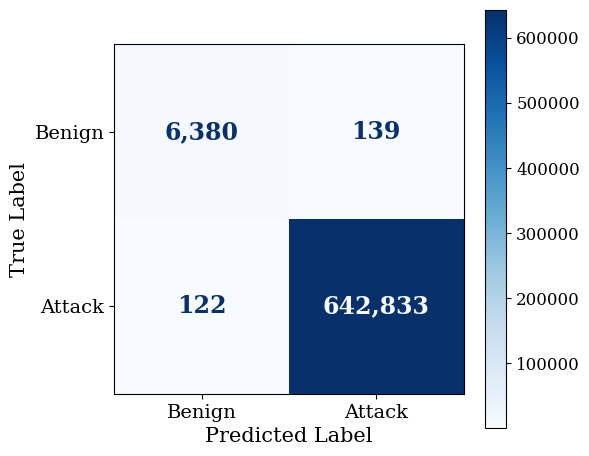

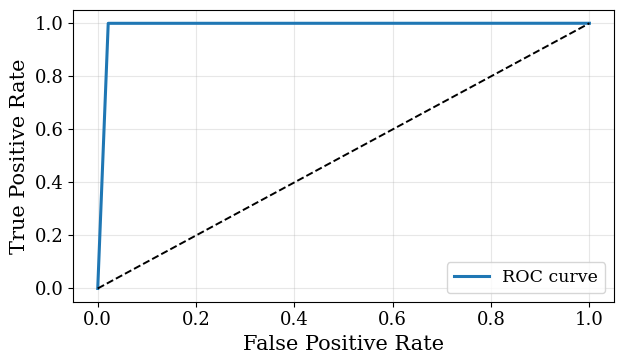

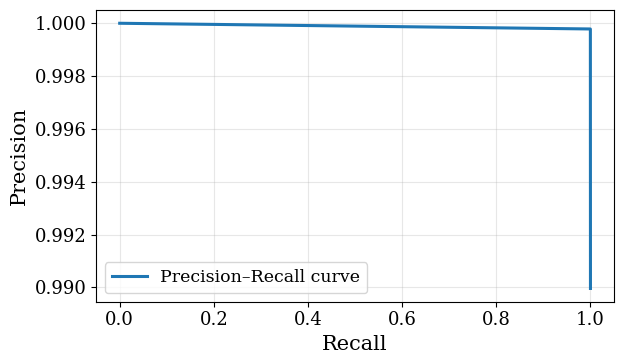


✓ Result saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_results.csv
✓ Model saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/Decision_Tree_Full.joblib


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

eval_full(
    "Decision Tree Full",
    dt_model
)

In [ ]:
print("=" * 70)
print("BINARY FINAL AUDIT")
print("=" * 70)

print("Cleaned dataset shape:", df.shape)
print("\nFull label distribution:")
print(df["Label"].value_counts().sort_index())

print("\nTraining shape:", X_train_full.shape)
print("Test shape:", X_test_full.shape)

print("\nTraining labels:")
print(y_train_full.value_counts().sort_index())

print("\nTest labels:")
print(y_test_full.value_counts().sort_index())

dt_pred_audit = dt_model.predict(X_test_full)
print("\nDecision Tree confusion matrix:")
print(confusion_matrix(y_test_full, dt_pred_audit))

print("\nDecision Tree metrics:")
print("Accuracy :", accuracy_score(y_test_full, dt_pred_audit))
print("Precision:", precision_score(y_test_full, dt_pred_audit))
print("Recall   :", recall_score(y_test_full, dt_pred_audit))
print("F1       :", f1_score(y_test_full, dt_pred_audit))

BINARY FINAL AUDIT
Cleaned dataset shape: (3247366, 80)

Full label distribution:
Label
0      32593
1    3214773
Name: count, dtype: int64

Training shape: (2597892, 79)
Test shape: (649474, 79)

Training labels:
Label
0      26074
1    2571818
Name: count, dtype: int64

Test labels:
Label
0      6519
1    642955
Name: count, dtype: int64

Decision Tree confusion matrix:
[[  6380    139]
 [   122 642833]]

Decision Tree metrics:
Accuracy : 0.9995981363380212
Precision: 0.9997838164025805
Recall   : 0.9998102511062205
F1       : 0.9997970335796666


### Train and Evaluate Random Forest Classifier


Model: Random Forest Full
Accuracy : 0.9991
Precision: 0.9997
Recall   : 0.9994
F1 Score : 0.9996
Train Time: 709.88 sec

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9446    0.9682    0.9563      6519
      Attack     0.9997    0.9994    0.9996    642955

    accuracy                         0.9991    649474
   macro avg     0.9722    0.9838    0.9779    649474
weighted avg     0.9991    0.9991    0.9991    649474



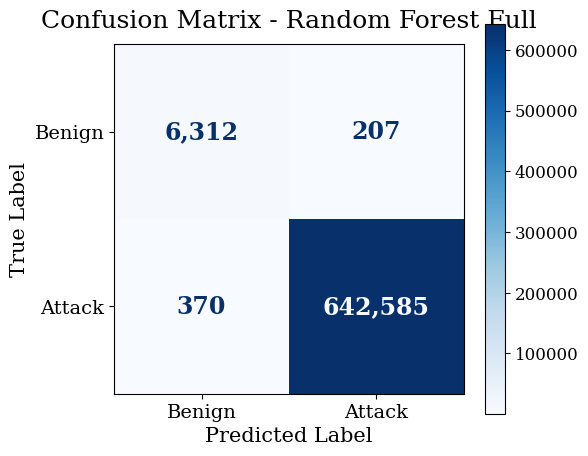

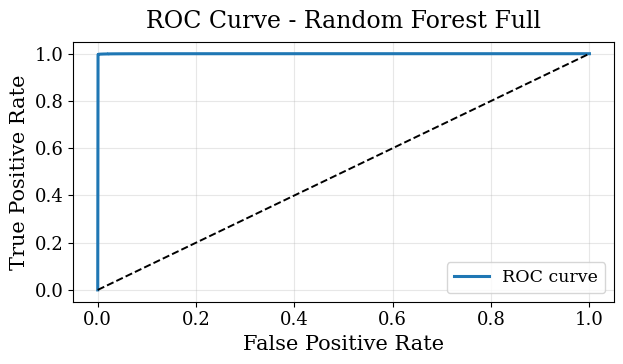

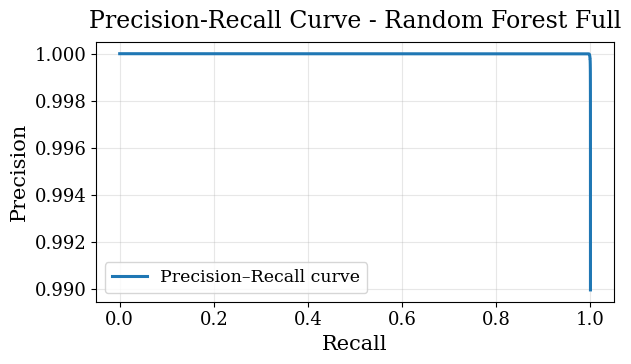


✓ Result saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_results.csv
✓ Model saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/Random_Forest_Full.joblib


RandomForestClassifier(class_weight='balanced', max_samples=0.5, n_jobs=-1,
                       random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    max_samples=0.5
)

eval_full(
    "Random Forest Full",
    rf_model
)

### Train and Evaluate Extra Trees Classifier


Model: Extra Trees Full
Accuracy : 0.9990
Precision: 0.9997
Recall   : 0.9993
F1 Score : 0.9995
Train Time: 226.70 sec

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9299    0.9692    0.9491      6519
      Attack     0.9997    0.9993    0.9995    642955

    accuracy                         0.9990    649474
   macro avg     0.9648    0.9842    0.9743    649474
weighted avg     0.9990    0.9990    0.9990    649474



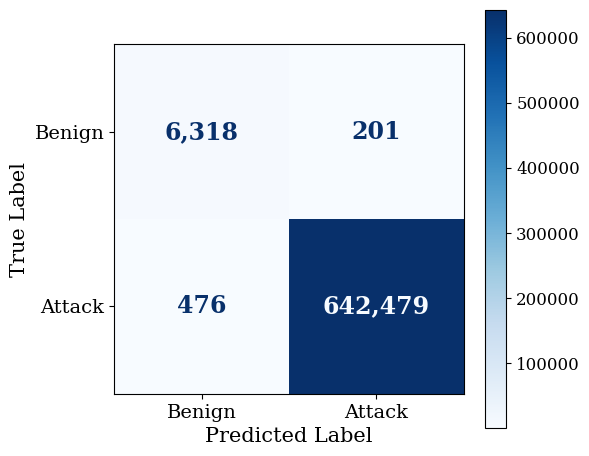

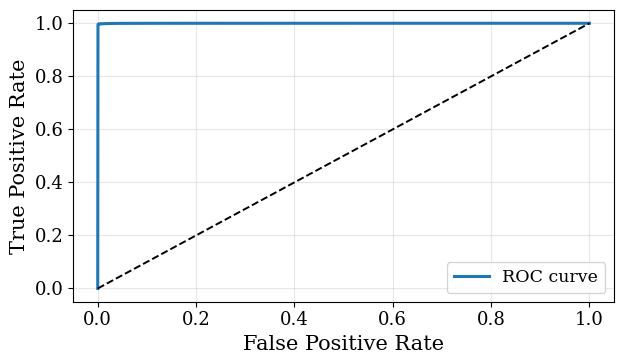

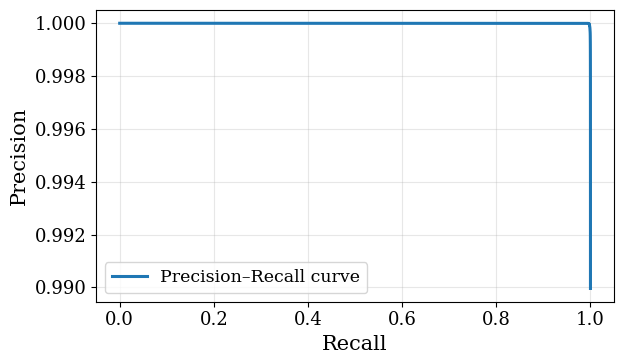


✓ Result saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_results.csv
✓ Model saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/Extra_Trees_Full.joblib


ExtraTreesClassifier(bootstrap=True, class_weight='balanced', max_samples=0.5,
                     n_jobs=-1, random_state=42)

In [12]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    bootstrap=True,
    max_samples=0.5
)

eval_full(
    "Extra Trees Full",
    et_model
)


### Train and Evaluate XGBoost Classifier


Model: XGBoost Full
Accuracy : 0.9993
Precision: 0.9998
Recall   : 0.9994
F1 Score : 0.9996
Train Time: 130.99 sec

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9465    0.9821    0.9639      6519
      Attack     0.9998    0.9994    0.9996    642955

    accuracy                         0.9993    649474
   macro avg     0.9731    0.9907    0.9818    649474
weighted avg     0.9993    0.9993    0.9993    649474



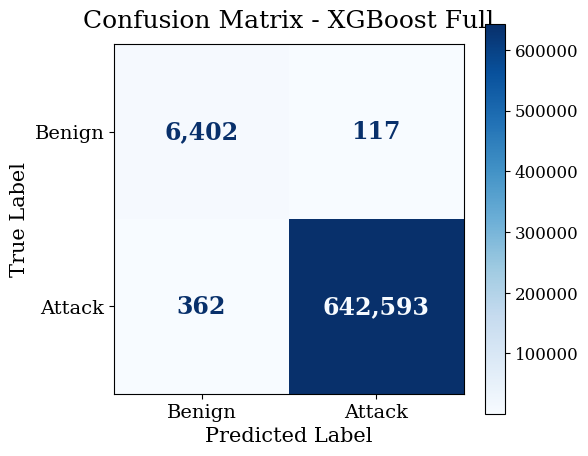

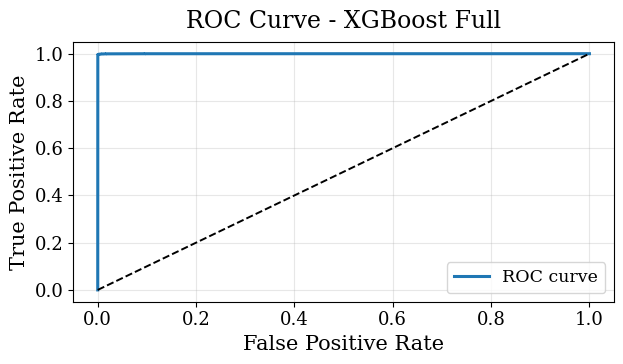

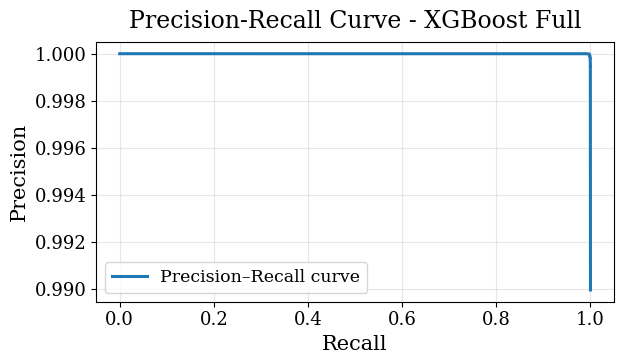


✓ Result saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_results.csv
✓ Model saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/XGBoost_Full.joblib


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

eval_full(
    "XGBoost Full",
    xgb_model
)

### Prepare Sample Data and Evaluation Function

### Initialize Additional Machine Learning Models

In [ ]:
import os
import time
import joblib
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# =====================================================
# Sample data
# =====================================================

X_base = X_train_full
y_base = y_train_full
X_test_base = X_test_full
y_test_base = y_test_full

TRAIN_SAMPLE_SIZE = 300000
TEST_SAMPLE_SIZE = 80000

X_sample, _, y_sample, _ = train_test_split(
    X_base,
    y_base,
    train_size=min(TRAIN_SAMPLE_SIZE, len(X_base)),
    random_state=42,
    stratify=y_base
)

X_test_sample, _, y_test_sample, _ = train_test_split(
    X_test_base,
    y_test_base,
    train_size=min(TEST_SAMPLE_SIZE, len(X_test_base)),
    random_state=42,
    stratify=y_test_base
)

scaler = StandardScaler()

X_sample_scaled = scaler.fit_transform(X_sample).astype("float32")
X_test_sample_scaled = scaler.transform(X_test_sample).astype("float32")

# =====================================================
# Persistent result/model paths
# =====================================================

ML_RESULT_FILE = f"{OUT_PATH}/binary_ml_results.csv"
ML_MODEL_DIR = f"{OUT_PATH}/binary_ml_models"

os.makedirs(ML_MODEL_DIR, exist_ok=True)

ML_RESULT_COLUMNS = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Train Time"
]

if os.path.exists(ML_RESULT_FILE):
    full_results_df = pd.read_csv(ML_RESULT_FILE)
else:
    full_results_df = pd.DataFrame(
        columns=ML_RESULT_COLUMNS
    )

# =====================================================
# Sample-model evaluation function
# =====================================================

def eval_sample(name, model, Xtr, ytr, Xte, yte):
    global full_results_df

    start = time.time()

    model.fit(Xtr, ytr)

    train_time = time.time() - start

    y_pred = model.predict(Xte)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(Xte)[:, 1]

    elif hasattr(model, "decision_function"):
        scores = model.decision_function(Xte)

        score_range = scores.max() - scores.min()

        if score_range == 0:
            y_prob = np.zeros_like(scores, dtype="float64")
        else:
            y_prob = (scores - scores.min()) / score_range

    else:
        y_prob = y_pred.astype("float64")

    acc = accuracy_score(yte, y_pred)
    pre = precision_score(yte, y_pred, zero_division=0)
    rec = recall_score(yte, y_pred, zero_division=0)
    f1 = f1_score(yte, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(yte, y_prob)

    precision_curve, recall_curve, _ = precision_recall_curve(
        yte,
        y_prob
    )


    print("\n" + "=" * 70)
    print("Model:", name)
    print("=" * 70)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Train Time: {train_time:.2f} sec")

    print("\nClassification Report:")
    print(
        classification_report(
            yte,
            y_pred,
            target_names=["Benign", "Attack"],
            digits=4,
            zero_division=0
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(yte, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Attack"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label="ROC curve"
    )
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Precision-Recall Curve
    plt.figure(figsize=(6, 5))
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label="Precision–Recall curve"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =================================================
    # Save/update result
    # =================================================

    result_row = pd.DataFrame([{
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1": f1,

        "Train Time": train_time
    }])

    full_results_df = full_results_df[
        full_results_df["Model"] != name
    ]

    full_results_df = pd.concat(
        [full_results_df, result_row],
        ignore_index=True
    )

    full_results_df.to_csv(
        ML_RESULT_FILE,
        index=False
    )

    safe_name = (
        name
        .replace(" ", "_")
        .replace("/", "_")
    )

    model_path = f"{ML_MODEL_DIR}/{safe_name}.joblib"

    joblib.dump(
        model,
        model_path
    )

    print("\n✓ Result saved:", ML_RESULT_FILE)
    print("✓ Model saved:", model_path)

    return model

### Train and Evaluate Logistic Regression Model


Model: Logistic Regression Sample
Accuracy : 0.9908
Precision: 0.9998
Recall   : 0.9909
F1 Score : 0.9953
Train Time: 17.84 sec

Classification Report:
              precision    recall  f1-score   support

      Benign     0.5228    0.9851    0.6831       803
      Attack     0.9998    0.9909    0.9953     79197

    accuracy                         0.9908     80000
   macro avg     0.7613    0.9880    0.8392     80000
weighted avg     0.9951    0.9908    0.9922     80000



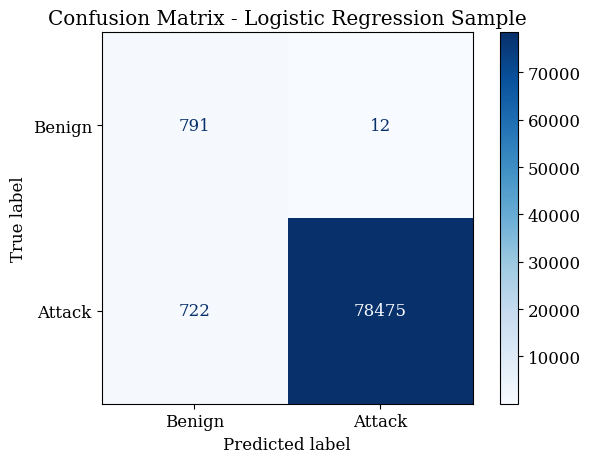

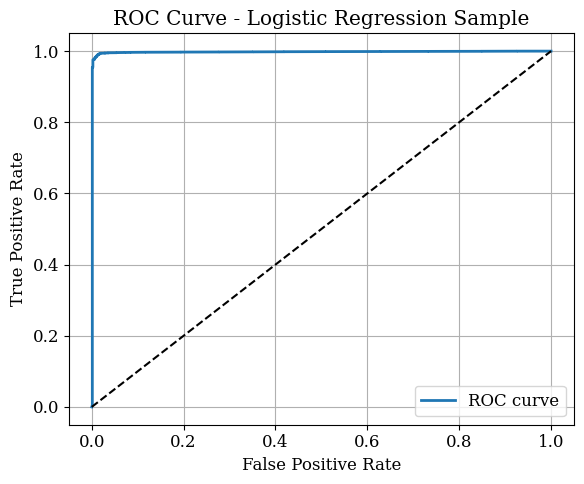

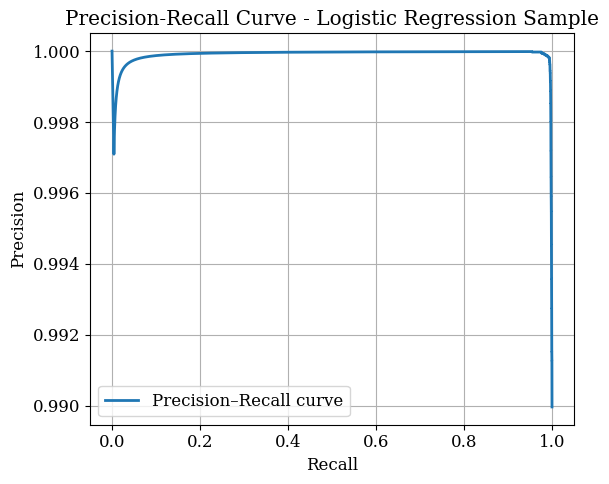


✓ Result saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_results.csv
✓ Model saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/Logistic_Regression_Sample.joblib


LogisticRegression(class_weight='balanced', max_iter=500, n_jobs=-1)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    n_jobs=-1
)

eval_sample("Logistic Regression Sample", lr_model, X_sample_scaled, y_sample, X_test_sample_scaled, y_test_sample)

### Train and Evaluate Gradient Boosting Classifier


Model: Gradient Boosting Sample
Accuracy : 0.9966
Precision: 0.9990
Recall   : 0.9976
F1 Score : 0.9983
ROC AUC  : 0.9983
PR AUC   : 1.0000
Train Time: 104.55 sec

Classification Report:
              precision    recall  f1-score   support

      Benign     0.7919    0.9004    0.8427       803
      Attack     0.9990    0.9976    0.9983     79197

    accuracy                         0.9966     80000
   macro avg     0.8954    0.9490    0.9205     80000
weighted avg     0.9969    0.9966    0.9967     80000



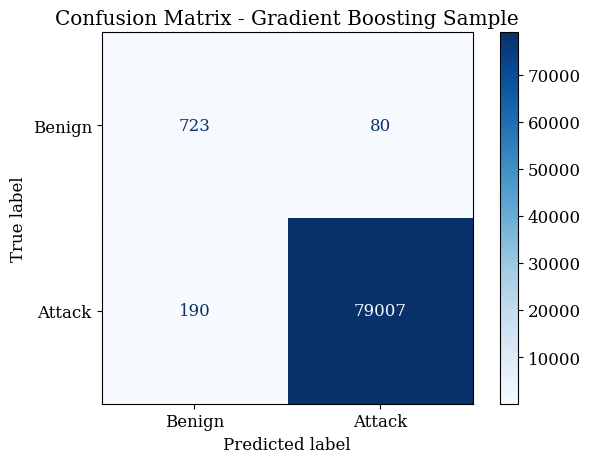

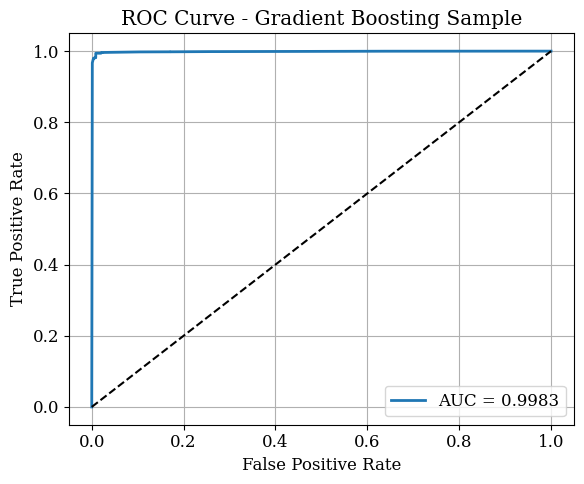

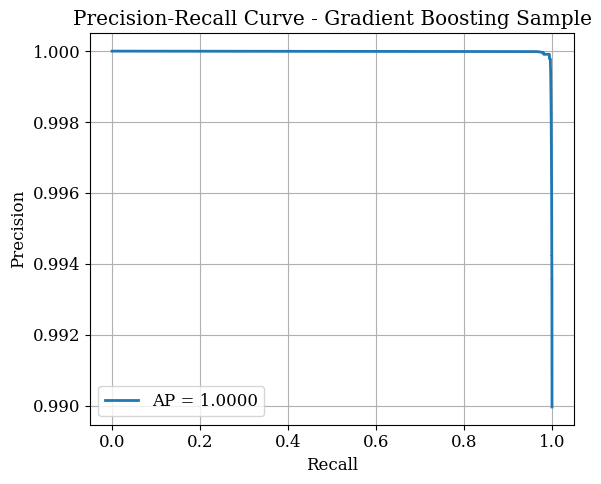


✓ Result saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_results.csv
✓ Model saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/Gradient_Boosting_Sample.joblib


GradientBoostingClassifier(max_depth=2, n_estimators=50, random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

eval_sample("Gradient Boosting Sample", gb_model, X_sample, y_sample, X_test_sample, y_test_sample)

### Train and Evaluate Support Vector Machine (SVM)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Model: Linear SVM Sample
Accuracy : 0.9901
Precision: 0.9998
Recall   : 0.9902
F1 Score : 0.9950
ROC AUC  : 0.9965
PR AUC   : 0.9998
Train Time: 1157.59 sec

Classification Report:
              precision    recall  f1-score   support

      Benign     0.5032    0.9838    0.6658       803
      Attack     0.9998    0.9902    0.9950     79197

    accuracy                         0.9901     80000
   macro avg     0.7515    0.9870    0.8304     80000
weighted avg     0.9948    0.9901    0.9917     80000



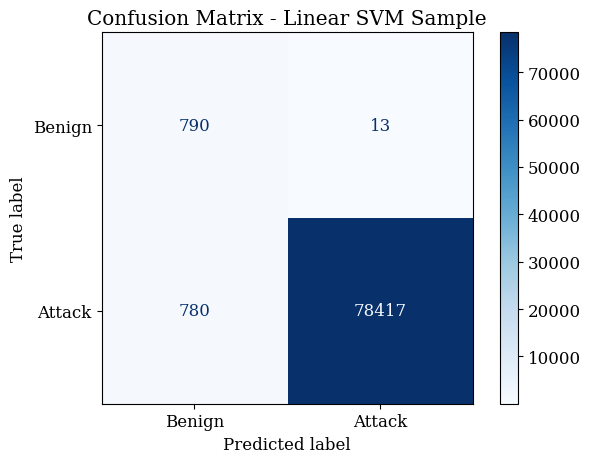

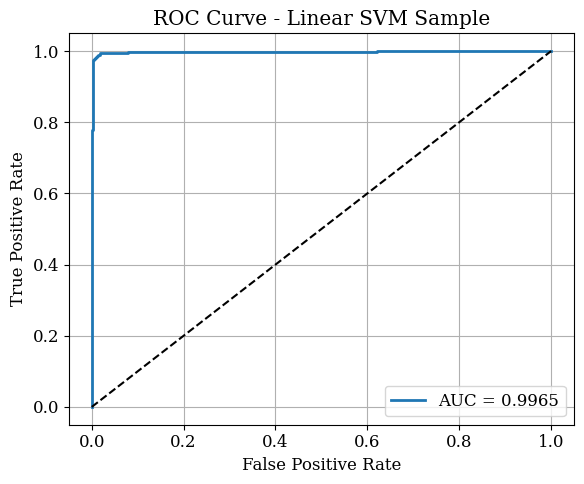

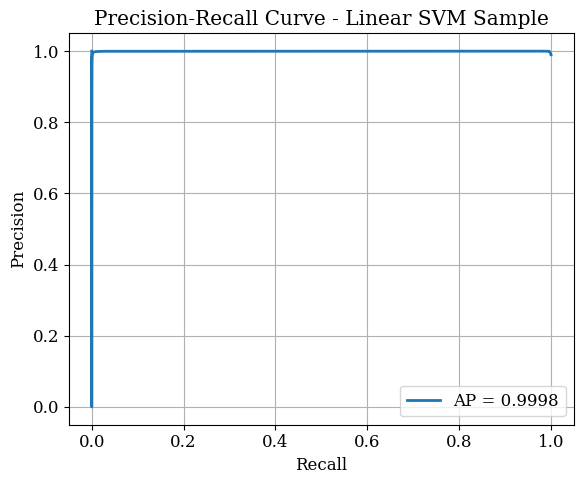


✓ Result saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_results.csv
✓ Model saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/Linear_SVM_Sample.joblib


LinearSVC(class_weight='balanced', max_iter=3000, random_state=42)

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)

eval_sample("Linear SVM Sample", svm_model, X_sample_scaled, y_sample, X_test_sample_scaled, y_test_sample)

### Train and Evaluate Voting Ensemble Classifier


Model: Voting Ensemble Sample
Accuracy : 0.9986
Precision: 0.9996
Recall   : 0.9990
F1 Score : 0.9993
Train Time: 49.38 sec

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9028    0.9601    0.9306       803
      Attack     0.9996    0.9990    0.9993     79197

    accuracy                         0.9986     80000
   macro avg     0.9512    0.9796    0.9649     80000
weighted avg     0.9986    0.9986    0.9986     80000



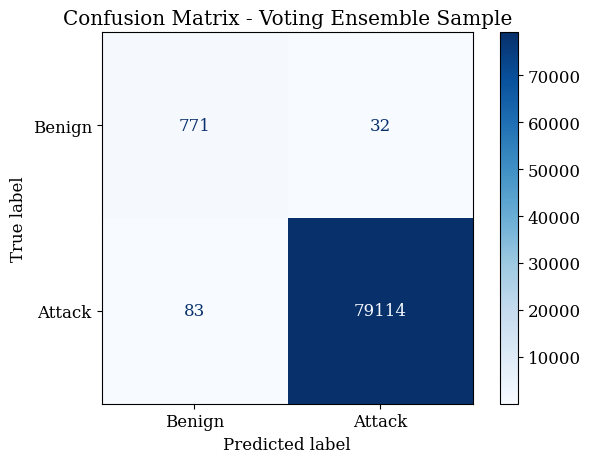

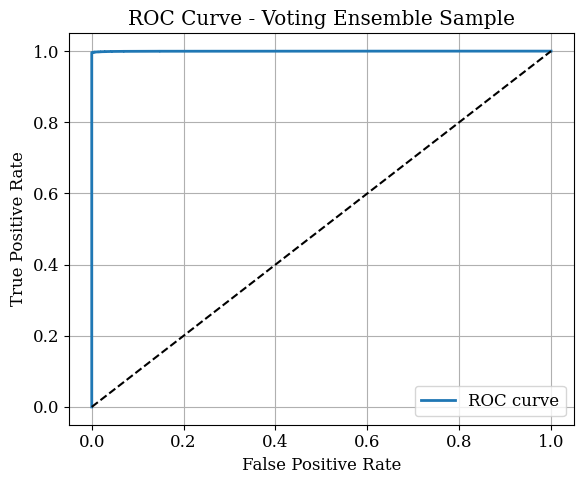

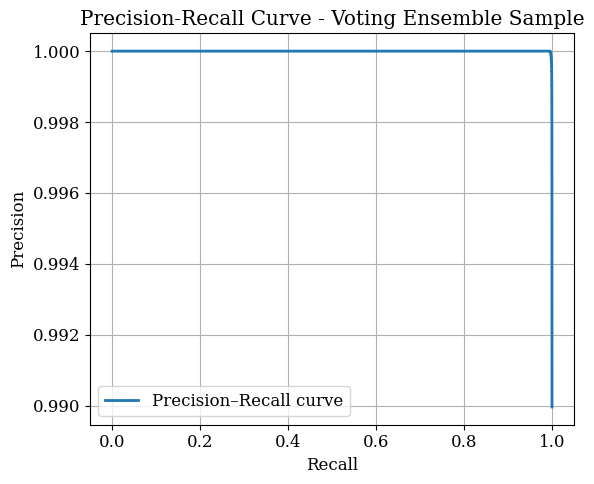


✓ Result saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_results.csv
✓ Model saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/Voting_Ensemble_Sample.joblib


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=30, n_jobs=-1,
                                                     random_state=42)),
                             ('et',
                              ExtraTreesClassifier(class_weight='balanced',
                                                   n_estimators=30, n_jobs=-1,
                                                   random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0....
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=50, n_jobs=-1,
                                            num_parallel_tree=None, ...))],
                 n_jobs=-1, voting='soft')

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

rf_vote = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

et_vote = ExtraTreesClassifier(
    n_estimators=30,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

xgb_vote = XGBClassifier(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

voting_model = VotingClassifier(
    estimators=[
        ("rf", rf_vote),
        ("et", et_vote),
        ("xgb", xgb_vote)
    ],
    voting="soft",
    n_jobs=-1
)

eval_sample("Voting Ensemble Sample", voting_model, X_sample, y_sample, X_test_sample, y_test_sample)

### Train and Evaluate K-Nearest Neighbors (KNN)


Model: KNN Sample
Accuracy : 0.9969
Precision: 0.9990
Recall   : 0.9978
F1 Score : 0.9984
ROC AUC  : 0.9844
PR AUC   : 0.9997
Train Time: 0.01 sec

Classification Report:
              precision    recall  f1-score   support

      Benign     0.8090    0.9003    0.8522       301
      Attack     0.9990    0.9978    0.9984     29699

    accuracy                         0.9969     30000
   macro avg     0.9040    0.9491    0.9253     30000
weighted avg     0.9971    0.9969    0.9969     30000



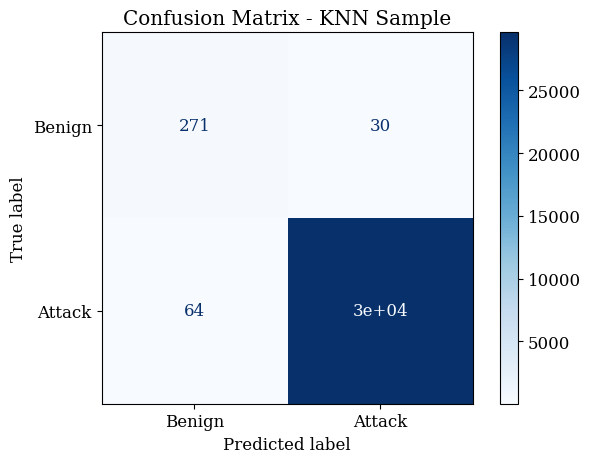

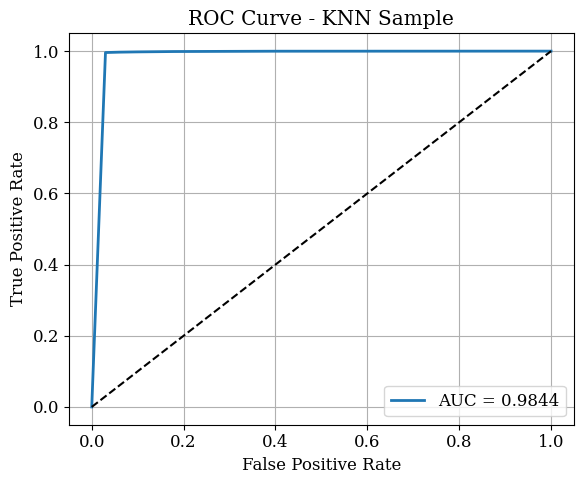

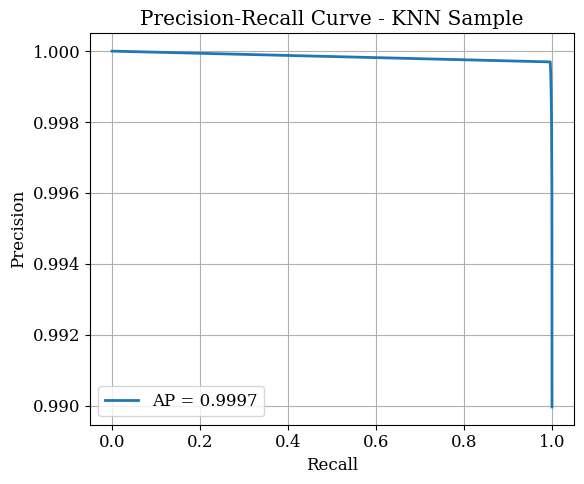


✓ Result saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_results.csv
✓ Model saved: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/KNN_Sample.joblib


KNeighborsClassifier(n_jobs=-1)

In [ ]:
from sklearn.model_selection import train_test_split

X_knn, _, y_knn, _ = train_test_split(
    X_sample_scaled, y_sample,
    train_size=min(80000, len(X_sample_scaled)),
    random_state=42,
    stratify=y_sample
)

X_knn_test, _, y_knn_test, _ = train_test_split(
    X_test_sample_scaled, y_test_sample,
    train_size=min(30000, len(X_test_sample_scaled)),
    random_state=42,
    stratify=y_test_sample
)

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

eval_sample("KNN Sample", knn_model, X_knn, y_knn, X_knn_test, y_knn_test)

### Compare Machine Learning Model Performance

In [ ]:
full_results_df = pd.read_csv(ML_RESULT_FILE)

full_results_df = (
    full_results_df
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

full_results_df

,Model,Accuracy,Precision,Recall,F1,Train Time
0,Decision Tree Full,0.9996,0.9998,0.9998,0.9998,124.7902
1,XGBoost Full,0.9993,0.9998,0.9994,0.9996,112.3078
2,Random Forest Full,0.9991,0.9997,0.9994,0.9996,605.8753
3,Extra Trees Full,0.9990,0.9997,0.9993,0.9995,214.7138
4,Voting Ensemble Sample,0.9986,0.9996,0.9990,0.9993,47.7322
5,KNN Sample,0.9969,0.9990,0.9978,0.9984,0.0113
6,Gradient Boosting Sample,0.9966,0.9990,0.9976,0.9983,104.5488
7,Logistic Regression Sample,0.9908,0.9998,0.9909,0.9953,17.8444
8,Linear SVM Sample,0.9901,0.9998,0.9902,0.9950,1157.5936


Save Train and Test Data for Deep Learning

In [ ]:
OUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"

train_full_df = X_train_full.copy()
train_full_df["Label"] = y_train_full.values

test_full_df = X_test_full.copy()
test_full_df["Label"] = y_test_full.values

train_full_df.to_csv(f"{OUT_PATH}/dl_train_full.csv", index=False)
test_full_df.to_csv(f"{OUT_PATH}/dl_test_full.csv", index=False)

print("Saved full DL train/test")

Saved full DL train/test


Verify Saved Machine Learning Models

In [ ]:
required_models = {
    "Decision Tree": "dt_model",
    "Random Forest": "rf_model",
    "Extra Trees": "et_model",
    "XGBoost": "xgb_model",
    "Voting Ensemble": "voting_model"
}

for model_name, variable_name in required_models.items():
    print(
        model_name,
        "exists:",
        variable_name in globals()
    )

print("X_test_full exists:", "X_test_full" in globals())
print("y_test_full exists:", "y_test_full" in globals())

Decision Tree exists: True
Random Forest exists: True
Extra Trees exists: True
XGBoost exists: True
Voting Ensemble exists: True
X_test_full exists: True
y_test_full exists: True


### Import Statistical Analysis Libraries

In [ ]:
import numpy as np
import pandas as pd

from statsmodels.stats.contingency_tables import mcnemar


def mcnemar_compare(
    reference_name,
    reference_pred,
    comparison_name,
    comparison_pred,
    y_true,
    alpha=0.05
):
    reference_correct = np.asarray(reference_pred) == np.asarray(y_true)
    comparison_correct = np.asarray(comparison_pred) == np.asarray(y_true)

    # Reference correct, comparison wrong
    b = np.sum(reference_correct & ~comparison_correct)

    # Reference wrong, comparison correct
    c = np.sum(~reference_correct & comparison_correct)

    table = [[0, b], [c, 0]]

    discordant_pairs = b + c

    if discordant_pairs == 0:
        statistic = 0.0
        p_value = 1.0
        method = "No discordant predictions"

    elif discordant_pairs < 25:
        result = mcnemar(
            table,
            exact=True
        )
        statistic = result.statistic
        p_value = result.pvalue
        method = "Exact McNemar"

    else:
        result = mcnemar(
            table,
            exact=False,
            correction=True
        )
        statistic = result.statistic
        p_value = result.pvalue
        method = "McNemar chi-square with correction"

    if p_value < alpha:
        significance = "Statistically significant"

        if b > c:
            conclusion = (
                f"{reference_name} made significantly more correct "
                f"predictions than {comparison_name}."
            )
        elif c > b:
            conclusion = (
                f"{comparison_name} made significantly more correct "
                f"predictions than {reference_name}."
            )
        else:
            conclusion = (
                "The difference is significant, but neither model "
                "has a directional advantage in discordant counts."
            )
    else:
        significance = "Not statistically significant"
        conclusion = (
            f"No statistically significant prediction difference "
            f"was found between {reference_name} and {comparison_name}."
        )

    return {
        "Reference Model": reference_name,
        "Comparison Model": comparison_name,
        "Reference Correct / Comparison Wrong": int(b),
        "Reference Wrong / Comparison Correct": int(c),
        "Discordant Predictions": int(discordant_pairs),
        "Test Method": method,
        "Statistic": float(statistic),
        "P-value": float(p_value),
        "Significance (α=0.05)": significance,
        "Conclusion": conclusion
    }

### Generate Predictions for McNemar's Test

In [ ]:
dt_pred = dt_model.predict(X_test_full)
rf_pred = rf_model.predict(X_test_full)
et_pred = et_model.predict(X_test_full)
xgb_pred = xgb_model.predict(X_test_full)
voting_pred = voting_model.predict(X_test_full)

print("Predictions completed.")
print("Test samples:", len(y_test_full))

Predictions completed.
Test samples: 649474


### Perform McNemar's Statistical Significance Test

In [ ]:
mcnemar_results = []

mcnemar_results.append(
    mcnemar_compare(
        "Decision Tree",
        dt_pred,
        "Random Forest",
        rf_pred,
        y_test_full
    )
)

mcnemar_results.append(
    mcnemar_compare(
        "Decision Tree",
        dt_pred,
        "Extra Trees",
        et_pred,
        y_test_full
    )
)

mcnemar_results.append(
    mcnemar_compare(
        "Decision Tree",
        dt_pred,
        "XGBoost",
        xgb_pred,
        y_test_full
    )
)

# Generate Voting Ensemble predictions on the same test set
voting_pred = voting_model.predict(X_test_full)

if len(voting_pred) != len(y_test_full):
    raise ValueError(
        "Voting Ensemble predictions and y_test_full "
        "do not contain the same number of samples."
    )

mcnemar_results.append(
    mcnemar_compare(
        "Decision Tree",
        dt_pred,
        "Voting Ensemble",
        voting_pred,
        y_test_full
    )
)

mcnemar_results_df = pd.DataFrame(mcnemar_results)

mcnemar_results_df

,Reference Model,Comparison Model,Reference Correct / Comparison Wrong,Reference Wrong / Comparison Correct,Discordant Predictions,Test Method,Statistic,P-value,Significance (α=0.05),Conclusion
0,Decision Tree,Random Forest,449,133,582,McNemar chi-square with correction,170.489691,5.783810e-39,Statistically significant,Decision Tree made significantly more correct ...
1,Decision Tree,Extra Trees,560,144,704,McNemar chi-square with correction,244.637784,3.832666e-55,Statistically significant,Decision Tree made significantly more correct ...
2,Decision Tree,XGBoost,381,163,544,McNemar chi-square with correction,86.560662,1.355161e-20,Statistically significant,Decision Tree made significantly more correct ...
3,Decision Tree,Voting Ensemble,830,138,968,McNemar chi-square with correction,493.265496,2.775123e-109,Statistically significant,Decision Tree made significantly more correct ...


### Summarize McNemar's Test Results

In [ ]:
mcnemar_summary = mcnemar_results_df[
    [
        "Reference Model",
        "Comparison Model",
        "Reference Correct / Comparison Wrong",
        "Reference Wrong / Comparison Correct",
        "Statistic",
        "P-value",
        "Significance (α=0.05)"
    ]
].copy()

mcnemar_summary["Statistic"] = (
    mcnemar_summary["Statistic"].round(4)
)

mcnemar_summary["P-value"] = (
    mcnemar_summary["P-value"].apply(
        lambda x: f"{x:.6g}"
    )
)

mcnemar_summary

,Reference Model,Comparison Model,Reference Correct / Comparison Wrong,Reference Wrong / Comparison Correct,Statistic,P-value,Significance (α=0.05)
0,Decision Tree,Random Forest,449,133,170.4897,5.78381e-39,Statistically significant
1,Decision Tree,Extra Trees,560,144,244.6378,3.83267e-55,Statistically significant
2,Decision Tree,XGBoost,381,163,86.5607,1.35516e-20,Statistically significant
3,Decision Tree,Voting Ensemble,830,138,493.2655,2.77512e-109,Statistically significant


### Model Predictions with SHAP (Beeswarm) plot

In [ ]:
!pip install shap -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

SHAP_PATH = f"{OUT_PATH}/shap_beeswarm"
os.makedirs(SHAP_PATH, exist_ok=True)

In [ ]:
def generate_shap_ml(
    model,
    model_name,
    X_train_data,
    X_test_data,
    feature_names,
    model_type="tree",
    class_index=1,
    background_size=100,
    explain_size=200
):
    print(f"Generating ML SHAP: {model_name}")

    # Convert train data to NumPy
    if isinstance(X_train_data, pd.DataFrame):
        X_train_np = X_train_data.to_numpy(dtype="float32")
    else:
        X_train_np = np.asarray(X_train_data, dtype="float32")

    # Convert test data to NumPy
    if isinstance(X_test_data, pd.DataFrame):
        X_test_np = X_test_data.to_numpy(dtype="float32")
    else:
        X_test_np = np.asarray(X_test_data, dtype="float32")

    rng = np.random.default_rng(42)

    background_idx = rng.choice(
        len(X_train_np),
        size=min(background_size, len(X_train_np)),
        replace=False
    )

    explain_idx = rng.choice(
        len(X_test_np),
        size=min(explain_size, len(X_test_np)),
        replace=False
    )

    background = X_train_np[background_idx]
    X_explain = X_test_np[explain_idx]

    # ==================================================
    # Tree models
    # ==================================================
    if model_type == "tree":

        model_class = model.__class__.__name__

        # XGBoost needs tree_path_dependent
        if model_class == "XGBClassifier":
            explainer = shap.TreeExplainer(
                model,
                feature_perturbation="tree_path_dependent"
            )

            raw_shap = explainer.shap_values(
                X_explain,
                check_additivity=False
            )

        # Decision Tree, Random Forest, Extra Trees
        else:
            explainer = shap.TreeExplainer(
                model,
                data=background,
                feature_perturbation="interventional"
            )

            raw_shap = explainer.shap_values(
                X_explain,
                check_additivity=False
            )

    # ==================================================
    # Linear models
    # ==================================================
    elif model_type == "linear":

        explainer = shap.LinearExplainer(
            model,
            background
        )

        raw_shap = explainer.shap_values(
            X_explain
        )

    else:
        raise ValueError(
            "model_type must be 'tree' or 'linear'"
        )

    # ==================================================
    # Select class-specific SHAP values
    # ==================================================
    if isinstance(raw_shap, list):
        shap_values = raw_shap[class_index]

    else:
        raw_shap = np.asarray(raw_shap)

        # Shape: samples × features × classes
        if raw_shap.ndim == 3:
            shap_values = raw_shap[:, :, class_index]

        # Shape: samples × features
        else:
            shap_values = raw_shap

    shap_values = np.asarray(shap_values)

    if shap_values.shape != X_explain.shape:
        raise ValueError(
            f"SHAP shape mismatch: {shap_values.shape}, "
            f"expected {X_explain.shape}"
        )

    # ==================================================
    # Beeswarm plot
    # ==================================================
    shap.summary_plot(
        shap_values,
        X_explain,
        feature_names=list(feature_names),
        plot_type="dot",
        max_display=30,
        show=False
    )

    plt.title(
        f"SHAP Summary (Beeswarm) — {model_name}"
    )
    plt.tight_layout()

    safe_name = (
        model_name
        .replace(" ", "_")
        .replace("/", "_")
    )

    figure_path = (
        f"{SHAP_PATH}/{safe_name}"
        f"_class_{class_index}_ml_shap.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", figure_path)

    return shap_values, X_explain

In [ ]:
import os

ML_MODEL_DIR = f"{OUT_PATH}/binary_ml_models"

print("ML model folder exists:", os.path.exists(ML_MODEL_DIR))

if os.path.exists(ML_MODEL_DIR):
    for file_name in os.listdir(ML_MODEL_DIR):
        print(file_name)

ML model folder exists: True
Random_Forest_Full.joblib
Extra_Trees_Full.joblib
KNN_Sample.joblib
Decision_Tree_Full.joblib
XGBoost_Full.joblib
Logistic_Regression_Sample.joblib
Gradient_Boosting_Sample.joblib
Linear_SVM_Sample.joblib
Voting_Ensemble_Sample.joblib


In [ ]:
import os
import joblib

ML_MODEL_DIR = f"{OUT_PATH}/binary_ml_models"

model_files = {
    "dt_model": "Decision_Tree_Full.joblib",
    "rf_model": "Random_Forest_Full.joblib",
    "et_model": "Extra_Trees_Full.joblib",
    "xgb_model": "XGBoost_Full.joblib",
    "lr_model": "Logistic_Regression_Sample.joblib",
    "gb_model": "Gradient_Boosting_Sample.joblib",
    "svm_model": "Linear_SVM_Sample.joblib",
    "knn_model": "KNN_Sample.joblib",
    "voting_model": "Voting_Ensemble_Sample.joblib"
}

for variable_name, file_name in model_files.items():
    model_path = os.path.join(
        ML_MODEL_DIR,
        file_name
    )

    if os.path.exists(model_path):
        globals()[variable_name] = joblib.load(
            model_path
        )
        print("Loaded:", variable_name, "from", file_name)
    else:
        print("Not found:", file_name)

Loaded: dt_model from Decision_Tree_Full.joblib
Loaded: rf_model from Random_Forest_Full.joblib
Loaded: et_model from Extra_Trees_Full.joblib
Loaded: xgb_model from XGBoost_Full.joblib
Loaded: lr_model from Logistic_Regression_Sample.joblib
Loaded: gb_model from Gradient_Boosting_Sample.joblib
Loaded: svm_model from Linear_SVM_Sample.joblib
Loaded: knn_model from KNN_Sample.joblib
Loaded: voting_model from Voting_Ensemble_Sample.joblib


SHAP Results for Decision Tree

Generating ML SHAP: Decision Tree Binary


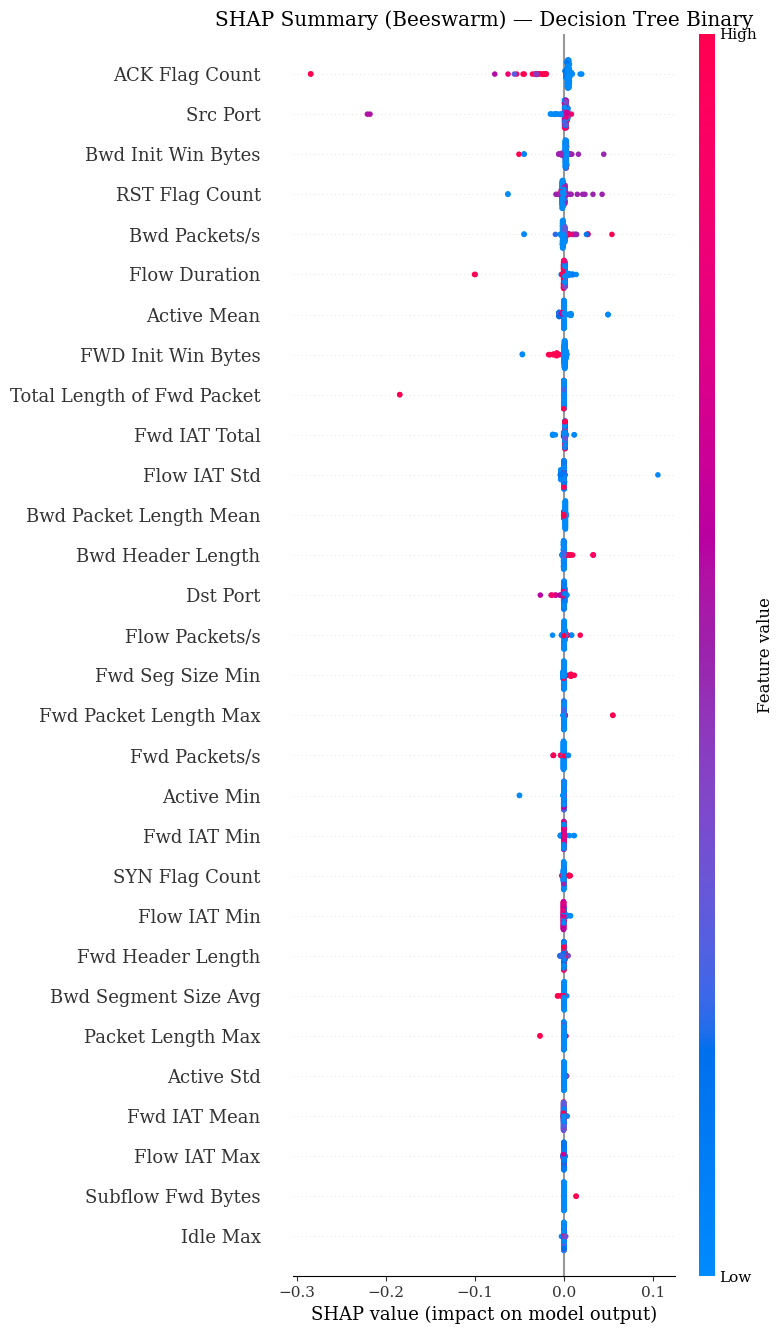

Saved: /content/drive/MyDrive/IoMT_Thesis_2024/shap_beeswarm/Decision_Tree_Binary_class_1_ml_shap.png


(array([[-2.18184760e-01,  2.95557229e-03,  0.00000000e+00, ...,
          0.00000000e+00,  1.86264515e-11,  0.00000000e+00],
        [ 2.01118341e-03,  1.90476193e-04,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 3.57539700e-03,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 2.27705632e-03,  1.90476198e-04,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 8.21428597e-04, -1.98412710e-04,  0.00000000e+00, ...,
          0.00000000e+00, -3.96825420e-05,  0.00000000e+00],
        [ 3.64754692e-03,  3.17460310e-05,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]),
 array([[3.5299000e+04, 1.8830000e+03, 6.0000000e+00, ..., 2.9307976e+03,
         5.0095590e+06, 5.0005640e+06],
        [3.7280000e+03, 6.6680000e+03, 6.0000000e+00, ..., 1.8712514e+06,
         9.1357710e+06, 5.6232020e+06],
 

In [ ]:
generate_shap_ml(
    model=dt_model,
    model_name="Decision Tree Binary",
    X_train_data=X_train_full,
    X_test_data=X_test_full,
    feature_names=feature_names,
    model_type="tree",
    class_index=1
)

SHAP Results for Random Forest

Generating ML SHAP: Random Forest Binary


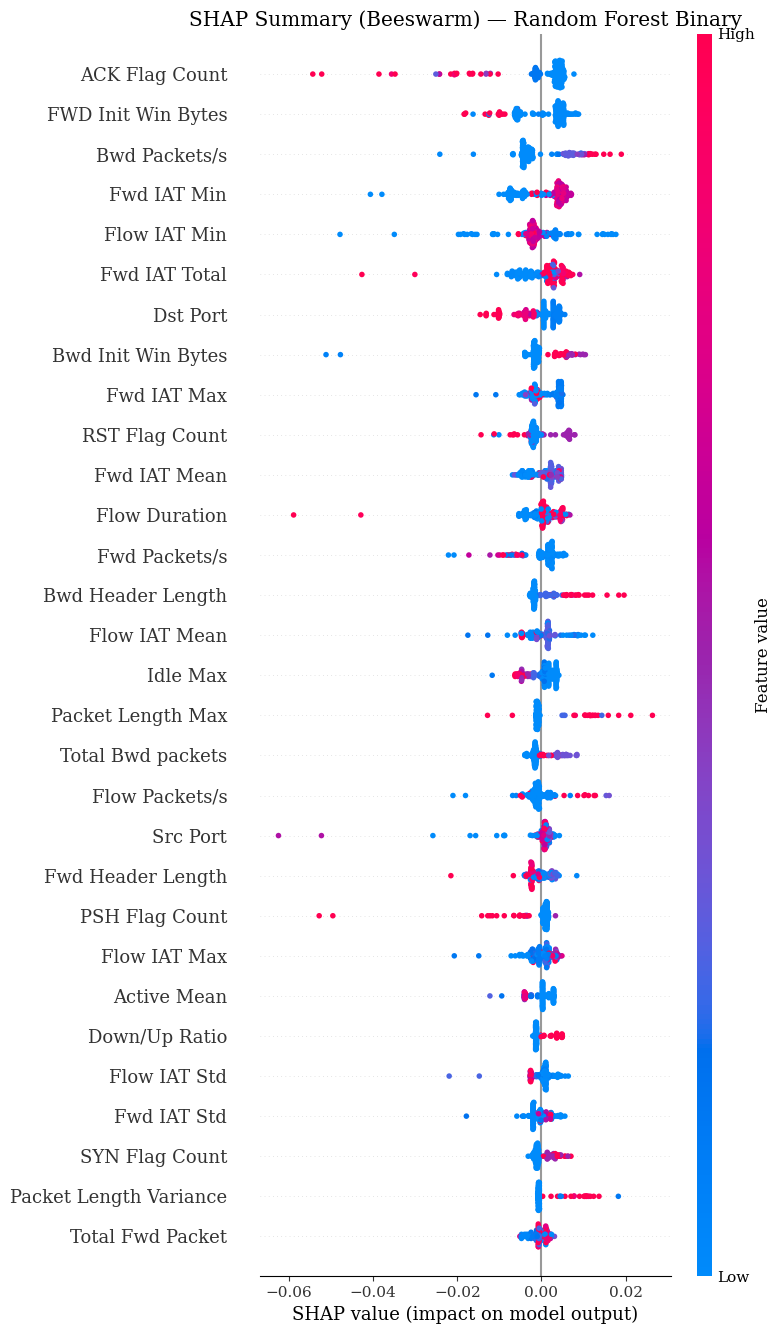

Saved: /content/drive/MyDrive/IoMT_Thesis_2024/shap_beeswarm/Random_Forest_Binary_class_1_ml_shap.png


(array([[-0.05226601, -0.00279958,  0.        , ..., -0.00979858,
         -0.00266111, -0.00164312],
        [ 0.00135178,  0.0041351 ,  0.        , ..., -0.00155193,
         -0.00189674,  0.00121781],
        [ 0.00073834,  0.00303415,  0.        , ...,  0.00076667,
          0.00015883,  0.00059131],
        ...,
        [ 0.00081757,  0.00282239,  0.        , ..., -0.00051853,
          0.00080819,  0.00025024],
        [ 0.00091394, -0.0101727 ,  0.        , ...,  0.00029464,
          0.00344915,  0.00066876],
        [ 0.00041205,  0.00113024,  0.        , ...,  0.000545  ,
          0.00369863,  0.00064638]]),
 array([[3.5299000e+04, 1.8830000e+03, 6.0000000e+00, ..., 2.9307976e+03,
         5.0095590e+06, 5.0005640e+06],
        [3.7280000e+03, 6.6680000e+03, 6.0000000e+00, ..., 1.8712514e+06,
         9.1357710e+06, 5.6232020e+06],
        [5.4415000e+04, 8.0000000e+03, 6.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        ...,
        [3.8148000

In [ ]:
generate_shap_ml(
    model=rf_model,
    model_name="Random Forest Binary",
    X_train_data=X_train_full,
    X_test_data=X_test_full,
    feature_names=feature_names,
    model_type="tree",
    class_index=1
)

SHAP Results for Extra Tress

Generating ML SHAP: Extra Trees Binary


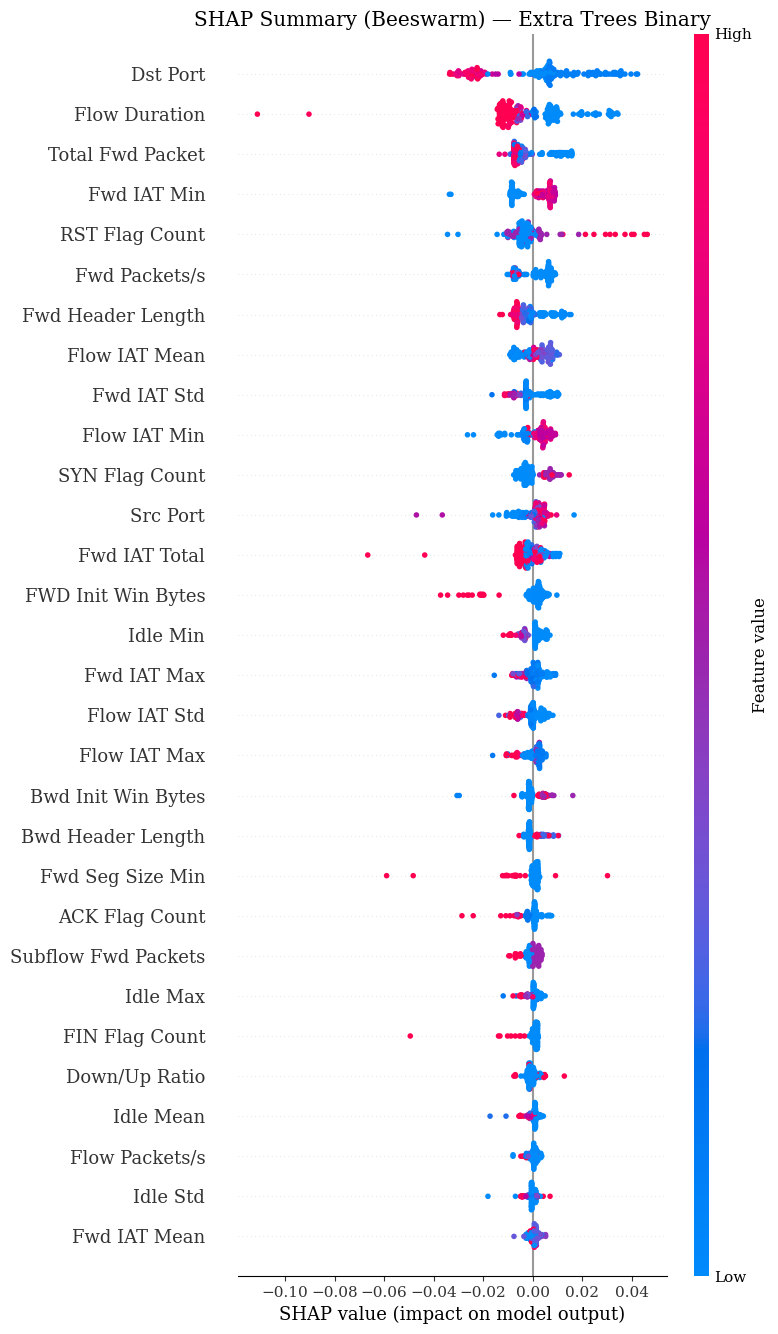

Saved: /content/drive/MyDrive/IoMT_Thesis_2024/shap_beeswarm/Extra_Trees_Binary_class_1_ml_shap.png


(array([[-0.03652246, -0.02436099,  0.        , ..., -0.00699889,
         -0.0066837 , -0.00581193],
        [-0.00317229,  0.01328873,  0.        , ..., -0.00200504,
         -0.00073208, -0.00349233],
        [ 0.00261287,  0.00561653,  0.        , ..., -0.00039687,
          0.00097425,  0.00117252],
        ...,
        [ 0.00411562,  0.00888339,  0.        , ..., -0.00087004,
          0.00027255, -0.00283908],
        [ 0.00218894, -0.02269246,  0.        , ...,  0.00079103,
          0.00182127,  0.0055673 ],
        [ 0.00240356,  0.00090433,  0.        , ..., -0.00045615,
          0.0015457 ,  0.00217457]]),
 array([[3.5299000e+04, 1.8830000e+03, 6.0000000e+00, ..., 2.9307976e+03,
         5.0095590e+06, 5.0005640e+06],
        [3.7280000e+03, 6.6680000e+03, 6.0000000e+00, ..., 1.8712514e+06,
         9.1357710e+06, 5.6232020e+06],
        [5.4415000e+04, 8.0000000e+03, 6.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        ...,
        [3.8148000

In [ ]:
generate_shap_ml(
    model=et_model,
    model_name="Extra Trees Binary",
    X_train_data=X_train_full,
    X_test_data=X_test_full,
    feature_names=feature_names,
    model_type="tree",
    class_index=1
)

SHAP Results for XGBoost

Generating ML SHAP: XGBoost Binary


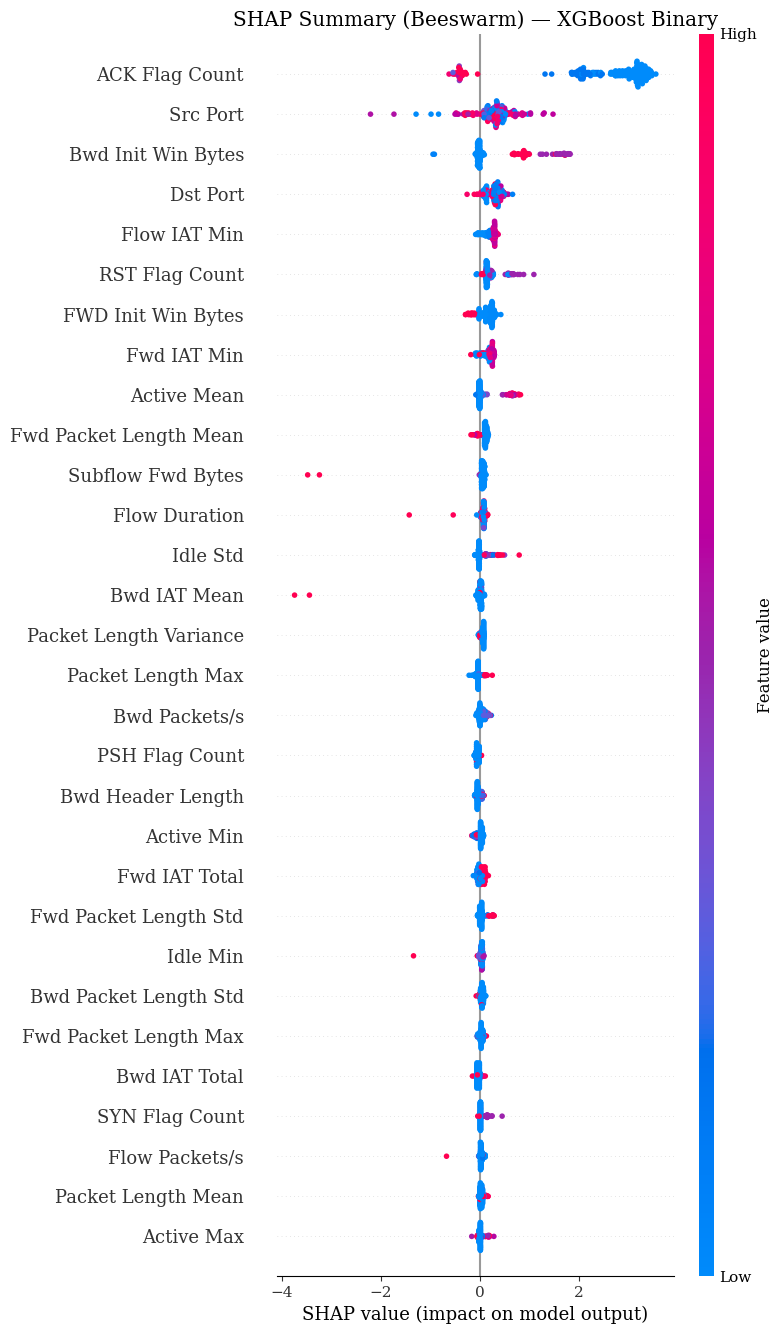

Saved: /content/drive/MyDrive/IoMT_Thesis_2024/shap_beeswarm/XGBoost_Binary_class_1_ml_shap.png


(array([[-1.73621643e+00,  7.28579536e-02,  0.00000000e+00, ...,
          3.96036822e-03,  3.18913697e-03,  2.16971077e-02],
        [ 1.38658494e-01,  3.01229835e-01,  0.00000000e+00, ...,
          1.23731904e-01,  2.17159395e-05,  3.67758945e-02],
        [ 3.40466678e-01,  3.70019019e-01,  0.00000000e+00, ...,
         -1.73629001e-02,  5.06619364e-03,  4.85289954e-02],
        ...,
        [ 1.27932358e+00,  3.08839977e-01,  0.00000000e+00, ...,
          5.43024391e-02, -1.40704471e-03,  4.50590532e-03],
        [ 3.47382039e-01,  3.14906120e-01,  0.00000000e+00, ...,
         -9.49513167e-03,  9.56634525e-03,  3.63591909e-02],
        [ 7.77458772e-02,  7.31789321e-02,  0.00000000e+00, ...,
         -1.44713363e-02,  5.72194206e-03,  4.91915196e-02]], dtype=float32),
 array([[3.5299000e+04, 1.8830000e+03, 6.0000000e+00, ..., 2.9307976e+03,
         5.0095590e+06, 5.0005640e+06],
        [3.7280000e+03, 6.6680000e+03, 6.0000000e+00, ..., 1.8712514e+06,
         9.1357710e+06, 5.

In [ ]:
generate_shap_ml(
    model=xgb_model,
    model_name="XGBoost Binary",
    X_train_data=X_train_full,
    X_test_data=X_test_full,
    feature_names=feature_names,
    model_type="tree",
    class_index=1
)

SHAP Results for Logistic Regression

Generating ML SHAP: Logistic Regression Binary


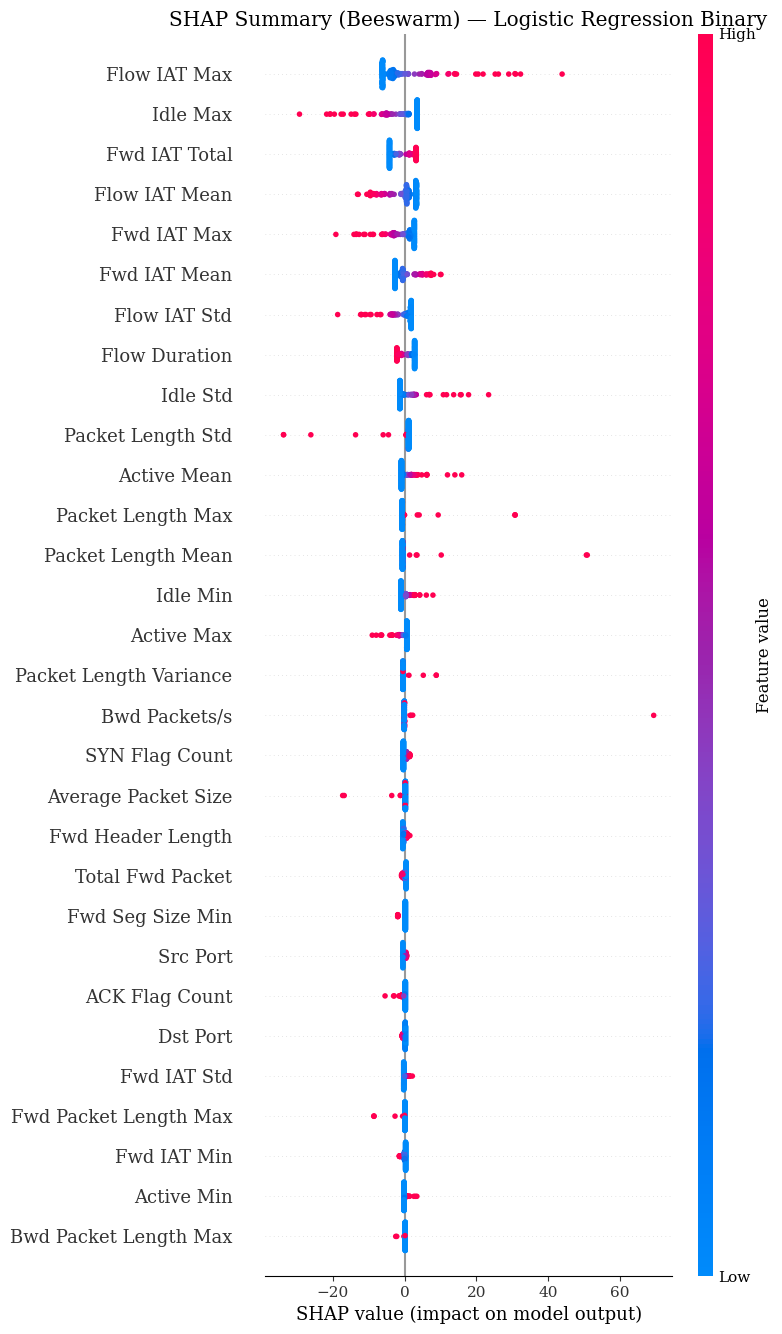

Saved: /content/drive/MyDrive/IoMT_Thesis_2024/shap_beeswarm/Logistic_Regression_Binary_class_1_ml_shap.png


(array([[ 0.21537354,  0.25687726,  0.        , ..., -1.29304035,
          3.53263912, -1.0102788 ],
        [-0.46649644, -0.63220598,  0.        , ..., -1.29304035,
          3.53263912, -1.0102788 ],
        [-0.3742901 ,  0.18575715,  0.        , ...,  2.40972147,
         -4.94787823,  0.27437059],
        ...,
        [ 0.07367945,  0.18575715,  0.        , ..., -1.29304035,
         -1.27698318,  1.50023992],
        [ 0.03884741,  0.16595944,  0.        , ..., -1.29304035,
          3.53263912, -1.0102788 ],
        [-0.25405386,  0.25687726,  0.        , ..., -1.29304035,
          1.21859184,  0.1976037 ]]),
 array([[ 0.6891098 , -0.82439816,  0.        , ..., -0.32624486,
         -0.51848286, -0.48517781],
        [-1.327819  ,  1.9458635 ,  0.        , ..., -0.32624486,
         -0.51848286, -0.48517781],
        [-1.0550784 , -0.6027976 ,  0.        , ...,  0.57639897,
          0.7866407 ,  0.19188997],
        ...,
        [ 0.2699875 , -0.6027976 ,  0.        , ..., -

In [ ]:
generate_shap_ml(
    model=lr_model,
    model_name="Logistic Regression Binary",
    X_train_data=X_sample_scaled,
    X_test_data=X_test_sample_scaled,
    feature_names=feature_names,
    model_type="linear",
    class_index=1
)

SHAP Results for Gradient Boosting

Generating ML SHAP: Gradient Boosting Binary


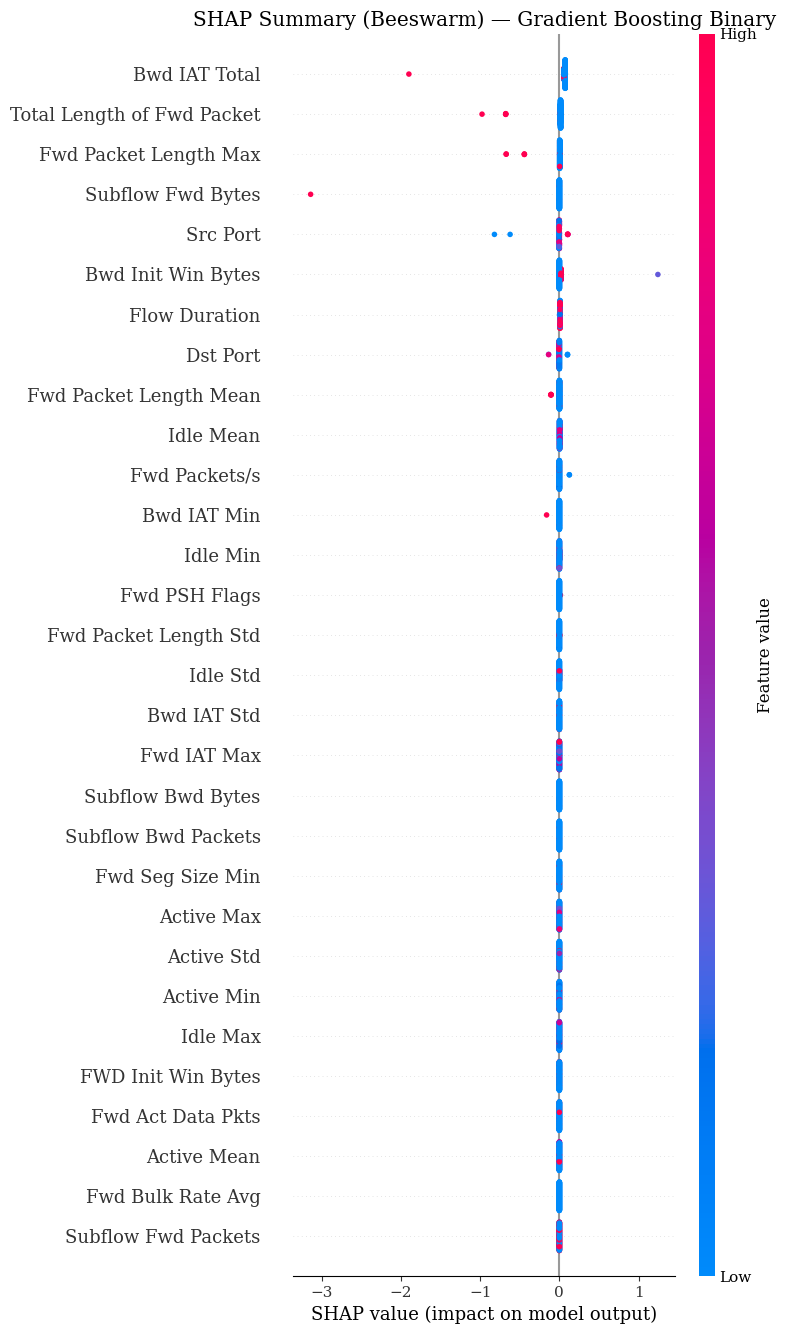

Saved: /content/drive/MyDrive/IoMT_Thesis_2024/shap_beeswarm/Gradient_Boosting_Binary_class_1_ml_shap.png


(array([[ 0.        ,  0.        ,  0.        , ..., -0.00028242,
          0.        ,  0.00026352],
        [-0.00650702, -0.00468527,  0.        , ..., -0.00028242,
          0.        ,  0.00026352],
        [-0.00313394,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.00026352],
        ...,
        [-0.00040193,  0.        ,  0.        , ..., -0.00028242,
          0.        ,  0.00026352],
        [-0.00313394, -0.00468527,  0.        , ..., -0.00028242,
          0.        ,  0.00026352],
        [-0.00313394,  0.        ,  0.        , ..., -0.00028242,
          0.        ,  0.00026352]]),
 array([[4.3407000e+04, 1.8830000e+03, 6.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [1.9060000e+03, 6.1701000e+04, 6.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [7.5180000e+03, 6.6680000e+03, 6.0000000e+00, ..., 4.7421130e+06,
         1.8556976e+07, 5.3853880e+06],
        ...,
        [3.4783000

In [ ]:
generate_shap_ml(
    model=gb_model,
    model_name="Gradient Boosting Binary",
    X_train_data=X_sample,
    X_test_data=X_test_sample,
    feature_names=feature_names,
    model_type="tree",
    class_index=1
)

SHAP Results for Linear SVM

Generating ML SHAP: Linear SVM Binary


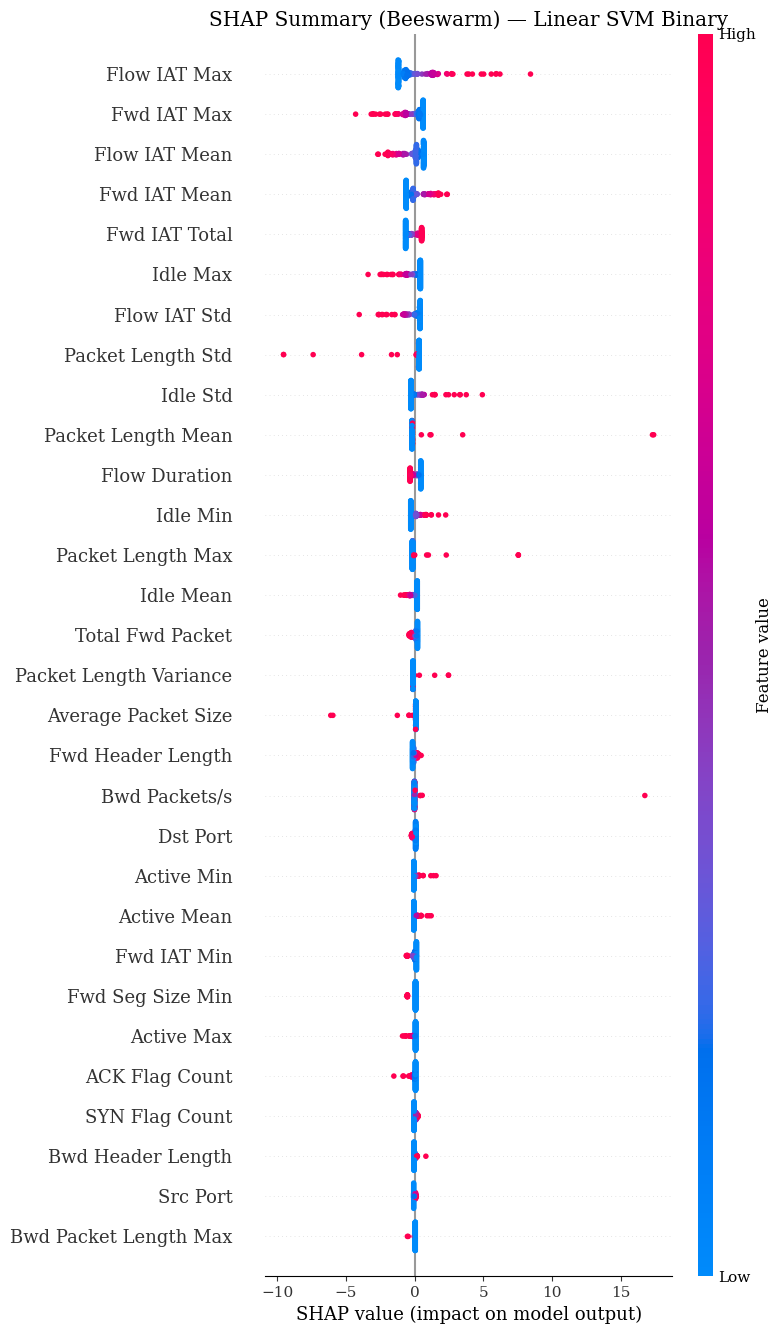

Saved: /content/drive/MyDrive/IoMT_Thesis_2024/shap_beeswarm/Linear_SVM_Binary_class_1_ml_shap.png


(array([[ 0.03337229,  0.09162224,  0.        , ..., -0.27139254,
          0.40873165, -0.28762354],
        [-0.07228398, -0.2254934 ,  0.        , ..., -0.27139254,
          0.40873165, -0.28762354],
        [-0.05799653,  0.06625532,  0.        , ...,  0.50576954,
         -0.57247694,  0.07811254],
        ...,
        [ 0.01141669,  0.06625532,  0.        , ..., -0.27139254,
         -0.14774887,  0.42711409],
        [ 0.00601944,  0.05919393,  0.        , ..., -0.27139254,
          0.40873165, -0.28762354],
        [-0.03936584,  0.09162224,  0.        , ..., -0.27139254,
          0.14099291,  0.05625722]]),
 array([[ 0.6891098 , -0.82439816,  0.        , ..., -0.32624486,
         -0.51848286, -0.48517781],
        [-1.327819  ,  1.9458635 ,  0.        , ..., -0.32624486,
         -0.51848286, -0.48517781],
        [-1.0550784 , -0.6027976 ,  0.        , ...,  0.57639897,
          0.7866407 ,  0.19188997],
        ...,
        [ 0.2699875 , -0.6027976 ,  0.        , ..., -

In [ ]:
generate_shap_ml(
    model=svm_model,
    model_name="Linear SVM Binary",
    X_train_data=X_sample_scaled,
    X_test_data=X_test_sample_scaled,
    feature_names=feature_names,
    model_type="linear",
    class_index=1
)

Decision Tree model found: /content/drive/MyDrive/IoMT_Thesis_2024/binary_ml_models/Decision_Tree_Full.joblib
Training dataset found   : /content/drive/MyDrive/IoMT_Thesis_2024/dl_train_full.csv
Test dataset found       : /content/drive/MyDrive/IoMT_Thesis_2024/dl_test_full.csv

Decision Tree model loaded successfully.
Model classes: [0 1]
Number of features: 79

LIME background shape: (2000, 79)
Background class counts: {0: 1000, 1: 1000}

Selected test position : 0
True label             : 1
Predicted label        : 1
Attack probability     : 1.0


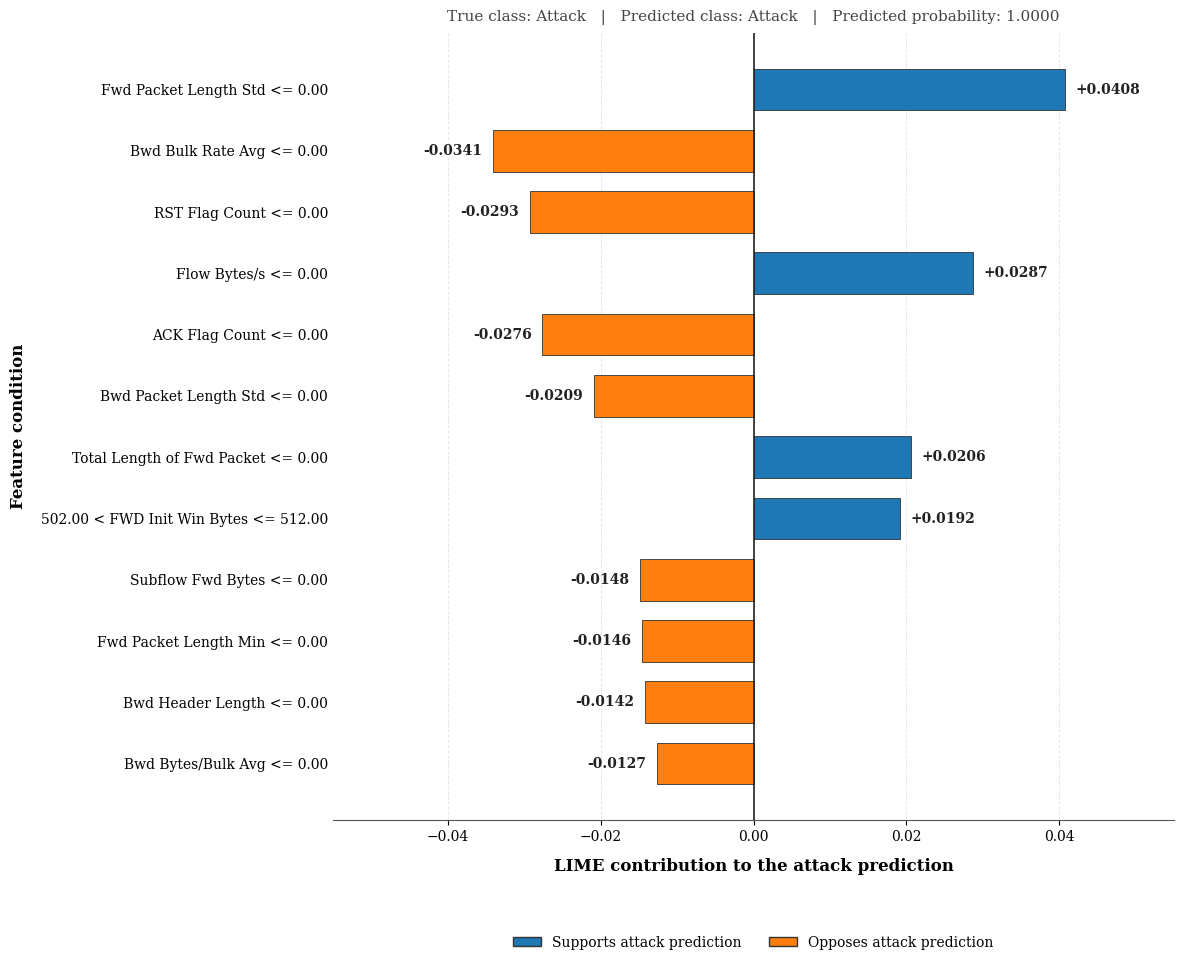


LIME PNG saved successfully:
/content/drive/MyDrive/IoMT_Thesis_2024/lime_figures/Decision_Tree_Full_LIME_Attack.png


In [15]:
# ============================================================
# DECISION TREE LIME — PUBLICATION-READY PNG ONLY
# Loads the saved model and data directly from Google Drive
# ============================================================

!pip install -q lime

import os
import textwrap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from google.colab import drive
from lime.lime_tabular import LimeTabularExplainer


# ============================================================
# 1. Mount Google Drive
# ============================================================

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")


# ============================================================
# 2. File paths
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Thesis_2024"

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "binary_ml_models",
    "Decision_Tree_Full.joblib"
)

TRAIN_DATA_PATH = os.path.join(
    PROJECT_DIR,
    "dl_train_full.csv"
)

TEST_DATA_PATH = os.path.join(
    PROJECT_DIR,
    "dl_test_full.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "lime_figures"
)

PNG_PATH = os.path.join(
    OUTPUT_DIR,
    "Decision_Tree_Full_LIME_Attack.png"
)


# ============================================================
# 3. Configuration
# ============================================================

TARGET_CLASS = 1
RANDOM_STATE = 42

BACKGROUND_PER_CLASS = 1000
BACKGROUND_CHUNK_SIZE = 100000

TEST_POOL_SIZE = 50000

NUM_FEATURES = 12
NUM_LIME_SAMPLES = 10000


# ============================================================
# 4. Validate required files
# ============================================================

required_files = {
    "Decision Tree model": MODEL_PATH,
    "Training dataset": TRAIN_DATA_PATH,
    "Test dataset": TEST_DATA_PATH
}

missing_files = [
    f"{name}: {path}"
    for name, path in required_files.items()
    if not os.path.exists(path)
]

if missing_files:
    raise FileNotFoundError(
        "The following required files were not found:\n\n"
        + "\n".join(missing_files)
    )

print("Decision Tree model found:", MODEL_PATH)
print("Training dataset found   :", TRAIN_DATA_PATH)
print("Test dataset found       :", TEST_DATA_PATH)


# ============================================================
# 5. Load the saved Decision Tree model
# ============================================================

dt_model = joblib.load(MODEL_PATH)

if not hasattr(dt_model, "predict_proba"):
    raise TypeError(
        "The loaded model does not support predict_proba()."
    )

print("\nDecision Tree model loaded successfully.")
print("Model classes:", dt_model.classes_)


# ============================================================
# 6. Recover the exact feature names and order
# ============================================================

if hasattr(dt_model, "feature_names_in_"):
    feature_names = list(dt_model.feature_names_in_)

else:
    saved_columns = pd.read_csv(
        TRAIN_DATA_PATH,
        nrows=0
    ).columns.tolist()

    feature_names = [
        column
        for column in saved_columns
        if column != "Label"
    ]

print("Number of features:", len(feature_names))


# ============================================================
# 7. Collect a class-balanced LIME background sample
# ============================================================

model_classes = np.asarray(dt_model.classes_)

background_storage = {
    int(class_value): []
    for class_value in model_classes
}

background_counts = {
    int(class_value): 0
    for class_value in model_classes
}

for chunk_number, chunk in enumerate(
    pd.read_csv(
        TRAIN_DATA_PATH,
        usecols=feature_names + ["Label"],
        chunksize=BACKGROUND_CHUNK_SIZE
    ),
    start=1
):

    chunk["Label"] = chunk["Label"].astype(np.int8)

    for class_value in model_classes:

        class_value = int(class_value)

        remaining = (
            BACKGROUND_PER_CLASS
            - background_counts[class_value]
        )

        if remaining <= 0:
            continue

        class_rows = chunk.loc[
            chunk["Label"] == class_value,
            feature_names
        ]

        if class_rows.empty:
            continue

        selected_rows = class_rows.sample(
            n=min(remaining, len(class_rows)),
            random_state=RANDOM_STATE + chunk_number + class_value
        )

        background_storage[class_value].append(
            selected_rows
        )

        background_counts[class_value] += len(
            selected_rows
        )

    if all(
        count >= BACKGROUND_PER_CLASS
        for count in background_counts.values()
    ):
        break


background_parts = []

for class_value in model_classes:

    class_value = int(class_value)

    if background_counts[class_value] == 0:
        raise RuntimeError(
            f"No background samples were found for class {class_value}."
        )

    class_background = pd.concat(
        background_storage[class_value],
        ignore_index=True
    ).iloc[:BACKGROUND_PER_CLASS]

    background_parts.append(class_background)


X_background = pd.concat(
    background_parts,
    ignore_index=True
)

X_background = X_background.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

X_background = X_background.astype(np.float32)

if not np.isfinite(X_background.to_numpy()).all():
    raise ValueError(
        "The LIME background data contains NaN or infinite values."
    )

print("\nLIME background shape:", X_background.shape)
print("Background class counts:", background_counts)


# ============================================================
# 8. Load a manageable test pool
# ============================================================

test_pool = pd.read_csv(
    TEST_DATA_PATH,
    usecols=feature_names + ["Label"],
    nrows=TEST_POOL_SIZE
)

test_pool["Label"] = test_pool["Label"].astype(np.int8)
test_pool[feature_names] = test_pool[feature_names].astype(
    np.float32
)

X_test_pool = test_pool[feature_names]
y_test_pool = test_pool["Label"].to_numpy()

if not np.isfinite(X_test_pool.to_numpy()).all():
    raise ValueError(
        "The test pool contains NaN or infinite values."
    )


# ============================================================
# 9. Select a representative correctly classified attack
# ============================================================

target_class_positions = np.flatnonzero(
    model_classes == TARGET_CLASS
)

if len(target_class_positions) == 0:
    raise ValueError(
        f"Target class {TARGET_CLASS} is not present in model.classes_."
    )

target_probability_column = int(
    target_class_positions[0]
)

test_predictions = dt_model.predict(
    X_test_pool
)

test_probabilities = dt_model.predict_proba(
    X_test_pool
)

candidate_positions = np.flatnonzero(
    (y_test_pool == TARGET_CLASS)
    &
    (test_predictions == TARGET_CLASS)
)

if len(candidate_positions) == 0:
    raise RuntimeError(
        "No correctly classified attack sample was found."
    )

candidate_probabilities = test_probabilities[
    candidate_positions,
    target_probability_column
]

median_probability = np.median(
    candidate_probabilities
)

selected_relative_position = np.argmin(
    np.abs(
        candidate_probabilities
        - median_probability
    )
)

selected_position = int(
    candidate_positions[selected_relative_position]
)

selected_instance = X_test_pool.iloc[
    selected_position
]

selected_probability = float(
    test_probabilities[
        selected_position,
        target_probability_column
    ]
)

selected_prediction = int(
    test_predictions[selected_position]
)

selected_true_label = int(
    y_test_pool[selected_position]
)

print("\nSelected test position :", selected_position)
print("True label             :", selected_true_label)
print("Predicted label        :", selected_prediction)
print("Attack probability     :", round(selected_probability, 6))


# ============================================================
# 10. Create the LIME explainer
# ============================================================

class_name_map = {
    0: "Benign",
    1: "Attack"
}

class_names = [
    class_name_map.get(
        int(class_value),
        str(class_value)
    )
    for class_value in model_classes
]

lime_explainer = LimeTabularExplainer(
    training_data=X_background.to_numpy(
        dtype=np.float32
    ),
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    discretizer="quartile",
    sample_around_instance=True,
    random_state=RANDOM_STATE
)


def decision_tree_predict_proba(lime_array):
    prediction_data = pd.DataFrame(
        lime_array,
        columns=feature_names
    ).astype(np.float32)

    return dt_model.predict_proba(
        prediction_data
    )


# ============================================================
# 11. Generate the LIME explanation
# ============================================================

lime_explanation = lime_explainer.explain_instance(
    data_row=selected_instance.to_numpy(
        dtype=np.float32
    ),
    predict_fn=decision_tree_predict_proba,
    labels=(target_probability_column,),
    num_features=min(
        NUM_FEATURES,
        len(feature_names)
    ),
    num_samples=NUM_LIME_SAMPLES,
    distance_metric="euclidean"
)


# ============================================================
# 12. Prepare explanation values for custom plotting
# ============================================================

explanation_values = lime_explanation.as_list(
    label=target_probability_column
)

explanation_df = pd.DataFrame(
    explanation_values,
    columns=[
        "Feature condition",
        "LIME contribution"
    ]
)

explanation_df = explanation_df.reindex(
    explanation_df[
        "LIME contribution"
    ].abs().sort_values().index
).reset_index(drop=True)

explanation_df["Wrapped feature"] = explanation_df[
    "Feature condition"
].apply(
    lambda value: "\n".join(
        textwrap.wrap(
            str(value),
            width=45
        )
    )
)


# ============================================================
# 13. Create a publication-ready custom LIME figure
# ============================================================

positive_color = "#1F77B4"
negative_color =  "#FF7F0E"

bar_colors = [
    positive_color if value >= 0
    else negative_color
    for value in explanation_df["LIME contribution"]
]

figure_height = max(
    6.5,
    0.62 * len(explanation_df) + 2.3
)

fig, ax = plt.subplots(
    figsize=(12, figure_height),
    facecolor="white"
)

bars = ax.barh(
    explanation_df["Wrapped feature"],
    explanation_df["LIME contribution"],
    color=bar_colors,
    edgecolor="#333333",
    linewidth=0.6,
    height=0.68
)

ax.axvline(
    x=0,
    color="#222222",
    linewidth=1.2
)

maximum_contribution = explanation_df[
    "LIME contribution"
].abs().max()

axis_limit = max(
    maximum_contribution * 1.35,
    0.01
)

ax.set_xlim(
    -axis_limit,
    axis_limit
)

for bar, contribution in zip(
    bars,
    explanation_df["LIME contribution"]
):
    y_position = bar.get_y() + bar.get_height() / 2

    horizontal_offset = axis_limit * 0.025

    if contribution >= 0:
        text_x = contribution + horizontal_offset
        alignment = "left"
    else:
        text_x = contribution - horizontal_offset
        alignment = "right"

    ax.text(
        text_x,
        y_position,
        f"{contribution:+.4f}",
        va="center",
        ha=alignment,
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )


#ax.set_title(
   # "Decision Tree Local Explanation for an Attack Prediction",
    #fontsize=16,
    #fontweight="bold",
    #pad=18
#)

ax.text(
    0.5,
    1.01,
    (
        f"True class: Attack   |   "
        f"Predicted class: Attack   |   "
        f"Predicted probability: {selected_probability:.4f}"
    ),
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color="#444444"
)

ax.set_xlabel(
    "LIME contribution to the attack prediction",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Feature condition",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.tick_params(
    axis="x",
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10,
    length=0
)

ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.30
)

ax.yaxis.grid(False)

ax.set_axisbelow(True)

legend_elements = [
    Patch(
        facecolor=positive_color,
        edgecolor="#333333",
        label="Supports attack prediction"
    ),
    Patch(
        facecolor=negative_color,
        edgecolor="#333333",
        label="Opposes attack prediction"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
    fontsize=10
)

for spine in [
    "top",
    "right",
    "left"
]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#555555")

plt.tight_layout()


# ============================================================
# 14. Save only the PNG file
# ============================================================

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)


# ============================================================
# 15. Final confirmation
# ============================================================

if os.path.exists(PNG_PATH):
    print("\nLIME PNG saved successfully:")
    print(PNG_PATH)
else:
    raise RuntimeError(
        "The PNG file could not be saved."
    )